In [1]:
import pandas as pd
import re
from tcr_toolbox.utils.plot_utils import startfig, set_mpl_params,simple_beeswarm2
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl, mylines = set_mpl_params(mpl=mpl)
from matplotlib.patches import Rectangle
import numpy as np
import pysam
from collections import defaultdict
from tcr_toolbox.sequencing_analysis.utils import remove_dna_barcode_from_string
from Bio.Seq import Seq
from pathlib import Path
from scipy.stats import mannwhitneyu
from adjustText import adjust_text
import itertools
from scipy.stats import spearmanr

from tcr_toolbox.epi_assembly_PRIVATE.mixmhcpred import parse_mixmhcpred_out_txt_list,run_mixmhcpred_patient_df_dict
from tcr_toolbox.epi_assembly_PRIVATE.epi_parse_utils import align_to_add_var_start_and_end_aa_seq_ag_df
from tcr_toolbox.sequencing_analysis_PRIVATE.plate_tcr_epi_count_analysis import read_gdna_counts_csv
from tcr_toolbox.utils.stat_utils import normalize_counts_df_by_total_counts

## Fig 3b and 3d, parse CD137 validation datasets Mel-Pt-B and NSCLC-Pt-C

In [ ]:
tcr_df = pd.read_csv("/mel_pt_b/CD137_percent_samples.csv")
tcr_df.rename({"Unnamed: 0": "Sample", "Lymphocytes/Single Cells/Alive/CD8+, GFP-/TCR+/CD137+ | Freq. of Parent (%)": "CD137_percent"}, axis =1 , inplace = True)
tcr_df = tcr_df.loc[tcr_df["Sample"].str.contains(".fcs"), :]
tcr_df.drop("Unnamed: 2", axis = 1, inplace = True)
tcr_df["CD137_percent"] = tcr_df["CD137_percent"].str.replace(",", ".", regex=False).astype(float)
tcr_df = tcr_df.loc[~tcr_df["Sample"].str.contains(r"PMA|UT|beads|media|SS", na=False), :]
tcr_df["Sample"] = tcr_df["Sample"].str.replace(".fcs", "")
tcr_df["Sample"] = tcr_df["Sample"].str.replace("1G4_NYESo_2", "1G4_NYESO_2")
sample_tcr_drop_list = ["39", "45"]
tcr_df = tcr_df.loc[~tcr_df["Sample"].str.contains(r"39|45|1G4"), :]

In [ ]:
new_tcr_df = pd.read_csv("/mel_pt_b/CD137_percentage_samples_new_TCRs.csv")
new_tcr_df.rename({"Unnamed: 0": "Sample", "Lymphocytes/Single Cells/alive+/CD8+ GFP-/TCR+/CD137+ | Freq. of Parent (%)": "CD137_percent"}, axis =1 , inplace = True)
new_tcr_df = new_tcr_df.loc[new_tcr_df["Sample"].str.contains(".fcs"), :]
new_tcr_df.drop("Unnamed: 2", axis = 1, inplace = True)
new_tcr_df["CD137_percent"] = new_tcr_df["CD137_percent"].str.replace(",", ".", regex=False).astype(float)
new_tcr_df = new_tcr_df.loc[~new_tcr_df["Sample"].str.contains(r"PMA|UT|beads|media|SS", na=False), :]
new_tcr_df["Sample"] = new_tcr_df["Sample"].str.replace(".fcs", "")

In [85]:
val_df = pd.concat([new_tcr_df, tcr_df], ignore_index= True)

In [86]:
val_df["Sample"].unique()

array(['1G4_B4', '1G4_NYESO', '1G4_NYESO_2', 'T23_B3_2', 'T23_B3',
       'T23_B4', 'T24_B4_2', 'T24_B4', 'T24_D9', 'T25_B3', 'T25_D9_2',
       'T25_D9', 'T26_B3_2', 'T26_B3', 'T26_D1', 'T27_B7', 'T27_D1_2',
       'T27_D1', 'T28_B7_2', 'T28_B7', 'T28_B8', 'T29_B8_2', 'T29_B8',
       'T29_C4', 'T30_B10', 'T30_C4_2', 'T30_C4', 'T31_B10_2', 'T31_B10',
       'T31_C7', 'T32_B12', 'T32_C7_2', 'T32_C7', 'T33_B12_2', 'T33_B12',
       'T33_C5', 'T39_C5_2', 'T39_C5', 'T39_C9', 'T43_C9_2', 'T43_C9',
       'T43_D2', 'T45_B4', 'T45_D2_2', 'T45_D2', '40_C6_2', '40_C6',
       '40_D3', '41_D3_2', '41_D3', '41_D4', '42_D5', '42_D6_2', '42_D6',
       '44_D6', '44_D7_2', '44_D7', '46_C6_2', '46_C6', '46_D8',
       '47_D4_2', '47_D4', '47_D8', '48_C5', '48_D5_2', '48_D5', '49_C6',
       '49_D8_2', '49_D8'], dtype=object)

In [ ]:
mel_pt_b_pair_map = {
    '1G4_B4': "neg_control-1G4-1",
 '1G4_NYESO':"NYESO1-1G4-1",
 '1G4_NYESO_2':"NYESO1-1G4-2",
 'T23_B3_2':"BBS12_E612Q-TCR_r7_2E4-2",
 'T23_B3':"BBS12_E612Q-TCR_r7_2E4-1",
 'T23_B4':"neg_control-TCR_r7_2E4-1",
 'T24_B4_2':"PGAP6_A52V-TCR_r7_2B19-2",
 'T24_B4':"PGAP6_A52V-TCR_r7_2B19-2",
 'T24_D9':"neg_control-TCR_r7_2B19-1",
 'T25_B3':"neg_control-TCR_r7_2D14-1",
 'T25_D9_2':"BUB1B_L575F-TCR_r7_2D14-2",
 'T25_D9':"BUB1B_L575F-TCR_r7_2D14-1",
 'T26_B3_2':"BBS12_E612Q-TCR_r7_2A23-2",
 'T26_B3':"BBS12_E612Q-TCR_r7_2A23-1",
 'T26_D1':'neg_control-TCR_r7_2A23-1',
 'T27_B7':"neg_control-TCR_r7_2A20-1",
 'T27_D1_2':"SCN2A_G266E-TCR_r7_2A20-2",
 'T27_D1':"SCN2A_G266E-TCR_r7_2A20-1",
 'T28_B7_2':'NBEA_D230N-TCR_r7_2D7-2',
 'T28_B7':"NBEA_D230N-TCR_r7_2D7-1",
 'T28_B8':"neg_control-TCR_r7_2D7-1",
 'T29_B8_2':"BICRAL_S805F-TCR_r7_2C19-2",
 'T29_B8':"BICRAL_S805F-TCR_r7_2C19-1",
 'T29_C4':"neg_control-TCR_r7_2C19-1",
 'T30_B10':"neg_control-TCR_r7_2C16-1",
 'T30_C4_2':"PSMA6_S17L-TCR_r7_2C16-2",
 'T30_C4':"PSMA6_S17L-TCR_r7_2C16-1",
 'T31_B10_2':"OBSCN_E2657K-TCR_r7_2C7-2",
 'T31_B10':"OBSCN_E2657K-TCR_r7_2C7-1",
 'T31_C7':"neg_control-TCR_r7_2C7-1",
 'T32_B12':"neg_control-TCR_r7_2B20-1",
 'T32_C7_2':"VIPAS39_R221Q-TCR_r7_2B20-2",
 'T32_C7':"VIPAS39_R221Q-TCR_r7_2B20-1",
 'T33_B12_2':"PKHD1L1_G3255E-TCR_r7_2B24-2",
 'T33_B12':"PKHD1L1_G3255E-TCR_r7_2B24-1",
 'T33_C5':"neg_control-TCR_r7_2B24-1",
 'T39_C5_2':"PGM2_P507L-TCR_r7_2D22-2",
 'T39_C5':"PGM2_P507L-TCR_r7_2D22-1",
 'T39_C9':"neg_control-TCR_r7_2D22-1",
 'T43_C9_2':"WNK1_P756S-TCR_r7_2A18-2",
 'T43_C9':"WNK1_P756S-TCR_r7_2A18-1",
 'T43_D2':"neg_control-TCR_r7_2A18-2",
 'T45_B4':"neg_control-TCR_r7_2D19-1",
 'T45_D2_2':"CDH17_R263W-TCR_r7_2D19-2",
 'T45_D2':"CDH17_R263W-TCR_r7_2D19-1", 

 '40_C6_2':"EFEMP2_E317DTNRCVE-TCR_r7_2D2-2", 
 '40_C6':"EFEMP2_E317DTNRCVE-TCR_r7_2D2-1",
 '40_D3':"neg_control-TCR_r7_2D2-2",
 '41_D3_2':"PIK3CB_D988E-TCR_r7_2D8-2", 
 '41_D3':"PIK3CB_D988E-TCR_r7_2D8-1",
 '41_D4':"neg_control-TCR_r7_2D8-1", 
 '42_D5':"neg_control-TCR_r7_2D6", 
 '42_D6_2':"PTPRO_S934F-TCR_r7_2D6-2", 
 '42_D6':"PTPRO_S934F-TCR_r7_2D6-1",
 '44_D6':"neg_control-TCR_r7_2A12-1", 
 '44_D7_2':"CSMD2_E1112D-TCR_r7_2A12-2",  
 '44_D7':"CSMD2_E1112D-TCR_r7_2A12-1",  
 '46_C6_2':"EFEMP2_E317DTNRCVE-TCR_r7_2B21-2", 
 '46_C6':"EFEMP2_E317DTNRCVE-TCR_r7_2B21-1", 
 '46_D8':"neg_control-TCR_r7_2B21-1",
 '47_D4_2':"FLT3_296fs-TCR_r7_2D20-2", 
 '47_D4':"FLT3_296fs-TCR_r7_2D20-1", 
 '47_D8':"neg_control-TCR_r7_2D20-1", 
 '48_C5':"neg_control-TCR_r7_2D17-1", 
 '48_D5_2':"SEPTIN2_P69S-TCR_r7_2D17-2", 
 '48_D5':"SEPTIN2_P69S-TCR_r7_2D17-1", 
 '49_C6':"neg_control-TCR_r7_2A17-1",
 '49_D8_2':"KCNQ5_L302F-TCR_r7_2A17-2", 
 '49_D8':"KCNQ5_L302F-TCR_r7_2A17-1",
}

In [ ]:
val_df["Pair"] = val_df["Sample"].map(mel_pt_b_pair_map)
if val_df["Pair"].isna().any():
    raise Exception("Not all samples are covered by mel-pt-b_pair_map!")

In [ ]:
pair_order_to_plot_list = ["NYESO1-1G4",
 "epi_mel_pt_b_BBS12_E612Q_432-tcr_1_2_E4_99_mel-pt-b_91", 
 "epi_mel_pt_b_BUB1B_L575F_188-tcr_1_2_D14_85_mel-pt-b_77",
 "epi_mel_pt_b_PGAP6_A52V_182-tcr_1_2_B19_42_mel-pt-b_34", 
 "epi_mel_pt_b_BBS12_E612Q_432-tcr_1_2_A23_22_mel-pt-b_14",
 "epi_mel_pt_b_PSMA6_S17L_47-tcr_1_2_C16_63_mel-pt-b_55",
 "epi_mel_pt_b_CDH17_R263W_741-tcr_1_2_D19_90_mel-pt-b_82",
 "epi_mel_pt_b_FLT3_296fs_661-tcr_1_2_D20_91_mel-pt-b_83", 
 "epi_mel_pt_b_NBEA_D230N_76-tcr_1_2_D7_78_mel-pt-b_70",
 ]

In [90]:
tcr_order_to_plot_list = [pair.split("-")[1].replace("tcr", "TCR") for pair in pair_order_to_plot_list]
tcr_order_to_plot_list = [
    re.sub(
        r"^TCR_1_2_([A-Z]\d+)_.*$",
        r"TCR_r7_2\1",
        s
    )
    for s in tcr_order_to_plot_list
]

In [91]:
tcr_order_to_plot_list

['1G4',
 'TCR_r7_2E4',
 'TCR_r7_2D14',
 'TCR_r7_2B19',
 'TCR_r7_2A23',
 'TCR_r7_2C16',
 'TCR_r7_2D19',
 'TCR_r7_2D20',
 'TCR_r7_2D7']

In [92]:
val_df = val_df.loc[
    val_df["Pair"].str.split("-").str[1].isin(tcr_order_to_plot_list)
].copy()

val_df["tcr"] = val_df["Pair"].str.split("-").str[1]

val_df["tcr"] = pd.Categorical(
    val_df["tcr"],
    categories=tcr_order_to_plot_list,
    ordered=True,
)

val_df = val_df.sort_values("tcr")

In [ ]:
val_df = val_df.loc[:, ["Pair", "CD137_percent", "Sample", "tcr"]]
val_df.to_excel('/mel-pt-b/final_mel-pt-b_validation_CD137_percent.xlsx',index = False)

## Fig. 1c

In [ ]:
mut_df = pd.read_csv('/publication/illustrator_figures/v1/figures/fig_1_pdfs/mut_burden_nostopgain_tpm1.txt', sep = '\t')
print(mut_df["burden"].quantile(0.95))

364.7999999999993


In [ ]:
print(mut_df["burden"].quantile(0.9815))

783.8880000000063


In [66]:
print(mut_df["burden"].quantile(0.996075))

3874.2786000000706


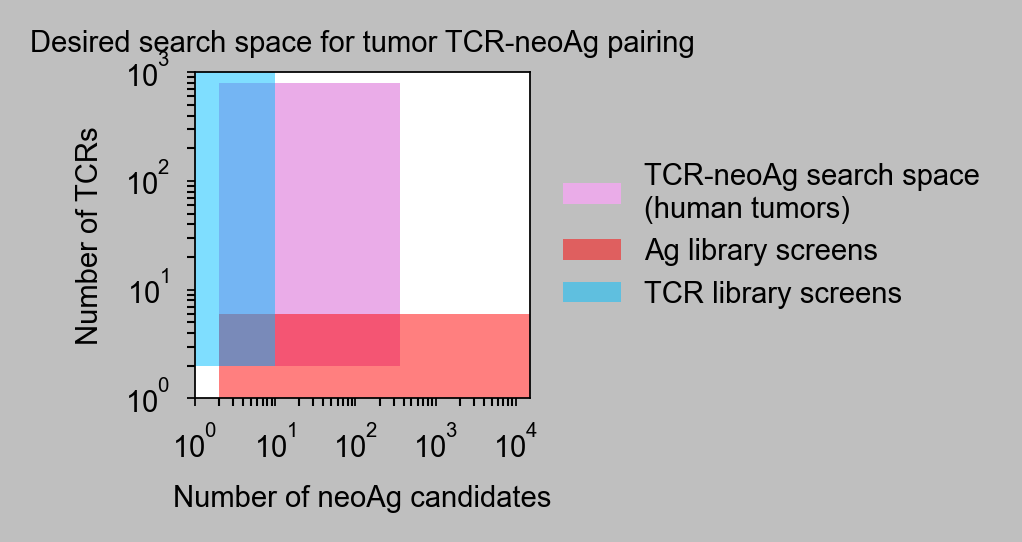

In [ ]:
ax, fig, gs = startfig(8.75, 5)

# Library-vs-Library 
ax.fill_between(
    [2, 365],
    2,
    800,
    color="#eaace8",
    edgecolor="none",
    alpha=1.0,
    label = "TCR-neoAg search space\n(human tumors)"
)

# neoAg/pMHC library screen 
ax.fill_between(
    [2, 3*10**5],
    1,
    6,
    #color="#eea1a4",
    color = "red", 
    edgecolor="none",
    alpha=0.5,
    label = "Ag library screens"
)

# TCR library screen
ax.fill_between(
    [1,10],
    2,
    30_000,
    #color="#bad2d7",
    color = "deepskyblue",
    edgecolor="none",
    alpha=0.5,
    label = "TCR library screens"
)


# Log axes
ax.set_xscale("log")
ax.set_yscale("log")

# Axis limits
ax.set_xlim(1, 15000)
ax.set_ylim(1, 1000)

ax.tick_params(
    axis="both",
    which="both",
    top=False,
    right=False,
    labeltop=False,
    labelright=False,
    labelsize=7,
)

ax.set_xlabel("Number of neoAg candidates", fontsize=7)
ax.set_ylabel("Number of TCRs", fontsize=7)

ax.legend(
    fontsize=7,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)
ax.set_title("Desired search space for tumor TCR-neoAg pairing", fontsize = 7)
fig.tight_layout()
fig.savefig('/v1/figures/fig_1_pdfs/fig_1c_num_TCRs_vs_num_neoAgs_illustration.pdf')
plt.show()

## Extended Data Fig. 5b, expected pair frequency hits vs non-hits

In [2]:
def make_exp_pair_mat(normalized_epitope_bulk_counts_df: pd.DataFrame, normalized_tcr_bulk_counts_df: pd.DataFrame, bulk_epitope_count_col: str = "read_count", bulk_tcr_count_col: str = "read_count"):
    if not normalized_epitope_bulk_counts_df.index[0].startswith("epi_"):
            print('Adding "epi_" prefix to normalized_epitope_bulk_counts_df reference names!')
            normalized_epitope_bulk_counts_df.index = ["epi_" + ref_name for ref_name in normalized_epitope_bulk_counts_df.index]

    if not normalized_tcr_bulk_counts_df.index[0].startswith("tcr_"):
        print('Adding "tcr_" prefix to normalized_epitope_bulk_counts_df reference names!')
        normalized_tcr_bulk_counts_df.index = ["tcr_" + ref_name for ref_name in normalized_tcr_bulk_counts_df.index]

    norm_row_sums_series = normalized_epitope_bulk_counts_df[bulk_epitope_count_col]
    norm_col_sums_series = normalized_tcr_bulk_counts_df[bulk_tcr_count_col]

    exp_pair_prob_matrix_arr = np.outer(norm_row_sums_series, norm_col_sums_series)
    exp_pair_prob_matrix_df = pd.DataFrame(exp_pair_prob_matrix_arr, index=norm_row_sums_series.index, columns=norm_col_sums_series.index)
    exp_pair_prob_matrix_df.index.name = "Epitope"
    exp_pair_prob_matrix_df.columns.name = "TCR"
    return exp_pair_prob_matrix_df

In [3]:
combined_validated = []
combined_not_validated = []

### Mel-Pt-A 200 vs 200 

In [ ]:
project_dir = Path('/data/mel-pt-a_T200_vs_Ag200_screen-1')

In [5]:
# 200 vs 200 run-1, Ag library
epi_bulk_counts_df = read_gdna_counts_csv(count_file = project_dir / 'bulk_seq_data/Ag/counts/7767_16_1-Ag200-2-bulk_GACCTGAA-CTCACCAA_S16_R1_001_trimmed_sorted_2ndfiltered_cigarmd_filtered_counts.csv',
                                          count_file_ref_name_col = 'reference_name',
                                          collapse_epitope_barcode = True,
                                          epitope_barcode_length = 18
                                          )

normalized_epi_bulk_counts_df_r1_2 = normalize_counts_df_by_total_counts(count_df = epi_bulk_counts_df, count_col = 'read_count')

In [6]:
# 200 vs 200 run-1, TCR library transduction rep-1
tcr_bulk_counts_df_1 = read_gdna_counts_csv(count_file = project_dir / 'bulk_seq_data/TCR/counts/7767_14_1-T200-1-bulk_TTACAGGA-GCTTGTCA_S14_R1_001_trimmed_sorted_2ndfiltered_cigarmd_filtered_counts.csv',
                                         count_file_ref_name_col = 'reference_name',
                                         )

normalized_tcr_bulk_counts_df_1 = normalize_counts_df_by_total_counts(count_df = tcr_bulk_counts_df_1, count_col = 'read_count')

In [7]:
# 200 vs 200 run-1, TCR library transduction rep-2
tcr_bulk_counts_df_2 = read_gdna_counts_csv(count_file = project_dir / 'bulk_seq_data/TCR/counts/7767_15_1-T200-2-bulk_GGCATTCT-CAAGCTAG_S15_R1_001_trimmed_sorted_2ndfiltered_cigarmd_filtered_counts.csv',
                                         count_file_ref_name_col = 'reference_name',
                                         )

normalized_tcr_bulk_counts_df_2 = normalize_counts_df_by_total_counts(count_df = tcr_bulk_counts_df_2, count_col = 'read_count')

In [8]:
print(len(set(normalized_tcr_bulk_counts_df_1.index).union(set(normalized_tcr_bulk_counts_df_2.index))))
print(len(set(normalized_tcr_bulk_counts_df_1.index).intersection(set(normalized_tcr_bulk_counts_df_2.index))))
print(len(set(normalized_tcr_bulk_counts_df_1.index).difference(set(normalized_tcr_bulk_counts_df_2.index))))
normalized_tcr_bulk_counts_df_r1_2 = normalized_tcr_bulk_counts_df_1.merge(normalized_tcr_bulk_counts_df_2, on = 'reference_name', suffixes = ('_1', '_2'))
print('Spearman’s rank correlation coefficient between T200-1 and T200-2:', normalized_tcr_bulk_counts_df_r1_2['read_count_1'].corr(normalized_tcr_bulk_counts_df_r1_2['read_count_2'], method = 'spearman'))
normalized_tcr_bulk_counts_df_r1_2['read_count'] = normalized_tcr_bulk_counts_df_r1_2.loc[:, ['read_count_1', 'read_count_2']].mean(axis = 1)
normalized_tcr_bulk_counts_df_r1_2.drop(['read_count_1', 'read_count_2'], axis = 1, inplace = True)
normalized_tcr_bulk_counts_df_r1_2['read_count'].isna().any()

180
180
0
Spearman’s rank correlation coefficient between T200-1 and T200-2: 0.8152984853895983


np.False_

In [ ]:
project_dir = Path('/data/mel-pt-a_T200_vs_Ag200_screen-2')

In [10]:
# # 200 vs 200 run-2, Ag library transduction rep-1, screen day 1
epi_bulk_counts_df_1 = read_gdna_counts_csv(count_file = project_dir / 'bulk_seq_data/Ag/counts/7864_3_v5_GCTTGTCA-GTATGTTC_S3_R1_001_trimmed_sorted_2ndfiltered_cigarmd_filtered_counts.csv',
                                          count_file_ref_name_col = 'reference_name',
                                          collapse_epitope_barcode = True,
                                          epitope_barcode_length = 18
                                          )
normalized_epi_bulk_counts_df_1 = normalize_counts_df_by_total_counts(count_df = epi_bulk_counts_df_1, count_col = 'read_count')                                     

In [11]:
# 200 vs 200 run-2, Ag library transduction rep-2, screen day 1
epi_bulk_counts_df_2 = read_gdna_counts_csv(count_file = project_dir / 'bulk_seq_data/Ag/counts/7864_4_v6_TGGATCGA-TATCGCAC_S4_R1_001_trimmed_sorted_2ndfiltered_cigarmd_filtered_counts.csv',
                                            count_file_ref_name_col = 'reference_name',
                                            collapse_epitope_barcode = True,
                                            epitope_barcode_length = 18
                                            )

normalized_epi_bulk_counts_df_2 = normalize_counts_df_by_total_counts(count_df = epi_bulk_counts_df_2, count_col = 'read_count')

In [ ]:
print(len(set(normalized_epi_bulk_counts_df_1.index).union(set(normalized_epi_bulk_counts_df_2.index))))
print(len(set(normalized_epi_bulk_counts_df_1.index).intersection(set(normalized_epi_bulk_counts_df_2.index))))
print(len(set(normalized_epi_bulk_counts_df_1.index).difference(set(normalized_epi_bulk_counts_df_2.index))))
normalized_epi_bulk_counts_df_r2 = normalized_epi_bulk_counts_df_1.merge(normalized_epi_bulk_counts_df_2,
                                                                      on='reference_name', suffixes=('_1', '_2'))
print('Spearman’s rank correlation coefficient between Ag200-rep-1 and Ag200-rep-2:',
      normalized_epi_bulk_counts_df_r2['read_count_1'].corr(normalized_epi_bulk_counts_df_r2['read_count_2'],
                                                         method='spearman'))
normalized_epi_bulk_counts_df_r2['read_count'] = normalized_epi_bulk_counts_df_r2.loc[:,['read_count_1', 'read_count_2']].mean(axis=1)

ax, fig, gs  = startfig(6,6)
color_list = []
text_list = []
for read_count_1, read_count_2, reference_name in zip(normalized_epi_bulk_counts_df_r2['read_count_1'],
                                                      normalized_epi_bulk_counts_df_r2['read_count_2'],
                                                      normalized_epi_bulk_counts_df_r2.index):
    if read_count_1 / read_count_2 > 1.75 or read_count_1 / read_count_2 < 1/1.75:
        color_list.append('lightblue')
        text_list.append(ax.text(read_count_1, read_count_2, reference_name, fontsize = 3, zorder = 8))
    else:
        color_list.append('lightgrey')
ax.scatter(normalized_epi_bulk_counts_df_r2['read_count_1'], normalized_epi_bulk_counts_df_r2['read_count_2'], color = color_list, s = 8)
ax.tick_params('both', labelsize = 7)
adjust_text(text_list,
            ax=ax,
            arrowprops=dict(arrowstyle='-', color='k', zorder=4, lw=0.25),
            )

normalized_epi_bulk_counts_df_r2.drop(['read_count_1', 'read_count_2'], axis=1, inplace=True)
normalized_epi_bulk_counts_df_r2['read_count'].isna().any()
ax.set_xlabel("Ag200 transduction rep-1", fontsize = 7)
ax.set_ylabel("Ag200 transduction rep-2 day-1", fontsize = 7)
ax.tick_params('both', labelsize = 7)

In [13]:
weights = [1819, 3395]
print(sum(weights))

5214


In [ ]:
print(len(set(normalized_epi_bulk_counts_df_r1_2.index).union(set(normalized_epi_bulk_counts_df_r2.index))))
print(len(set(normalized_epi_bulk_counts_df_r1_2.index).intersection(set(normalized_epi_bulk_counts_df_r2.index))))
print(len(set(normalized_epi_bulk_counts_df_r1_2.index).difference(set(normalized_epi_bulk_counts_df_r2.index))))
normalized_epi_bulk_counts_df = normalized_epi_bulk_counts_df_r1_2.merge(normalized_epi_bulk_counts_df_r2,
                                                                      on='reference_name', suffixes=('_1', '_2'))
print('Spearman’s rank correlation coefficient between Ag200-run-1-2 and Ag200-run-2:',
      normalized_epi_bulk_counts_df['read_count_1'].corr(normalized_epi_bulk_counts_df['read_count_2'],
                                                         method='spearman'))
normalized_epi_bulk_counts_df['read_count'] = normalized_epi_bulk_counts_df.loc[:,['read_count_1', 'read_count_2']].dot(weights) / sum(weights)

ax, fig, gs  = startfig(6,6)
color_list = []
text_list = []
for read_count_1, read_count_2, reference_name in zip(normalized_epi_bulk_counts_df['read_count_1'],
                                                      normalized_epi_bulk_counts_df['read_count_2'],
                                                      normalized_epi_bulk_counts_df.index):
    if read_count_1 / read_count_2 > 1.75 or read_count_1 / read_count_2 < 1/1.75:
        color_list.append('lightblue')
        text_list.append(ax.text(read_count_1, read_count_2, reference_name, fontsize = 3, zorder = 8))
    else:
        color_list.append('lightgrey')
ax.scatter(normalized_epi_bulk_counts_df['read_count_1'], normalized_epi_bulk_counts_df['read_count_2'], color = color_list, s = 8)
ax.tick_params('both', labelsize = 7)
adjust_text(text_list,
            ax=ax,
            arrowprops=dict(arrowstyle='-', color='k', zorder=4, lw=0.25),
            )

normalized_epi_bulk_counts_df.drop(['read_count_1', 'read_count_2'], axis=1, inplace=True)
normalized_epi_bulk_counts_df['read_count'].isna().any()
ax.set_xlabel("Ag200 transduction run-1-2", fontsize = 7)
ax.set_ylabel("Ag200 transduction run-2 rep-combined", fontsize = 7)
ax.tick_params('both', labelsize = 7)

In [15]:
# 200 vs 200 run-2, TCR library transduction rep-1, screen day 1
tcr_bulk_counts_df_1 = read_gdna_counts_csv(count_file = project_dir / 'bulk_seq_data/TCR/counts/7864_1_v1_TTACAGGA-GCTTGTCA_S1_R1_001_trimmed_sorted_2ndfiltered_cigarmd_filtered_counts.csv',
                                            count_file_ref_name_col = 'reference_name',
                                            )

normalized_tcr_bulk_counts_df_1 = normalize_counts_df_by_total_counts(count_df = tcr_bulk_counts_df_1, count_col = 'read_count')

In [16]:
# 200 vs 200 run-2, TCR library transduction rep-2, screen day 1
tcr_bulk_counts_df_2 = read_gdna_counts_csv(count_file = project_dir / 'bulk_seq_data/TCR/counts/7864_2_v2_GGCATTCT-CAAGCTAG_S2_R1_001_trimmed_sorted_2ndfiltered_cigarmd_filtered_counts.csv',
                                            count_file_ref_name_col = 'reference_name',
                                            )

normalized_tcr_bulk_counts_df_2 = normalize_counts_df_by_total_counts(count_df = tcr_bulk_counts_df_2, count_col = 'read_count')

In [17]:
print(len(set(normalized_tcr_bulk_counts_df_1.index).union(set(normalized_tcr_bulk_counts_df_2.index))))
print(len(set(normalized_tcr_bulk_counts_df_1.index).intersection(set(normalized_tcr_bulk_counts_df_2.index))))
print(len(set(normalized_tcr_bulk_counts_df_1.index).difference(set(normalized_tcr_bulk_counts_df_2.index))))
normalized_tcr_bulk_counts_df_r2 = normalized_tcr_bulk_counts_df_1.merge(normalized_tcr_bulk_counts_df_2, on = 'reference_name', suffixes = ('_1', '_2'))
print('Spearman’s rank correlation coefficient between T200-1 and T200-2:', normalized_tcr_bulk_counts_df_r2['read_count_1'].corr(normalized_tcr_bulk_counts_df_r2['read_count_2'], method = 'spearman'))
normalized_tcr_bulk_counts_df_r2['read_count'] = normalized_tcr_bulk_counts_df_r2.loc[:, ['read_count_1', 'read_count_2']].mean(axis = 1)
normalized_tcr_bulk_counts_df_r2.drop(['read_count_1', 'read_count_2'], axis = 1, inplace = True)
normalized_tcr_bulk_counts_df_r2['read_count'].isna().any()

181
180
1
Spearman’s rank correlation coefficient between T200-1 and T200-2: 0.8396705846768149


np.False_

180
180
0
Spearman’s rank correlation coefficient between T200-run-1-2 and T200-run-2: 0.9816516970688395


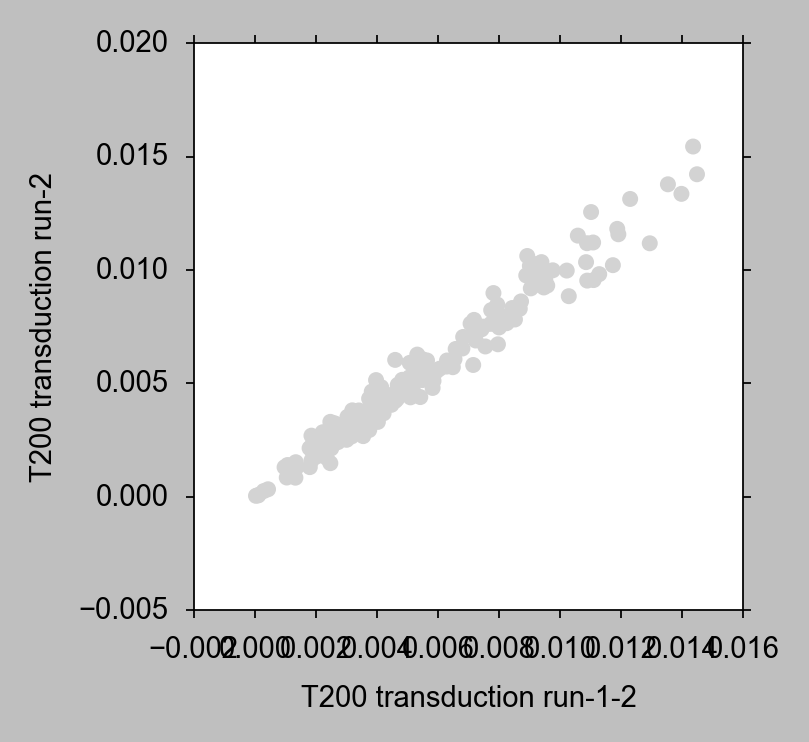

In [18]:
print(len(set(normalized_tcr_bulk_counts_df_r1_2.index).union(set(normalized_tcr_bulk_counts_df_r2.index))))
print(len(set(normalized_tcr_bulk_counts_df_r1_2.index).intersection(set(normalized_tcr_bulk_counts_df_r2.index))))
print(len(set(normalized_tcr_bulk_counts_df_r1_2.index).difference(set(normalized_tcr_bulk_counts_df_r2.index))))
normalized_tcr_bulk_counts_df = normalized_tcr_bulk_counts_df_r1_2.merge(normalized_tcr_bulk_counts_df_r2,
                                                                      on='reference_name', suffixes=('_1', '_2'))
print('Spearman’s rank correlation coefficient between T200-run-1-2 and T200-run-2:',
      normalized_tcr_bulk_counts_df['read_count_1'].corr(normalized_tcr_bulk_counts_df['read_count_2'],
                                                         method='spearman'))
normalized_tcr_bulk_counts_df['read_count'] = normalized_tcr_bulk_counts_df.loc[:,['read_count_1', 'read_count_2']].dot(weights) / sum(weights)

ax, fig, gs  = startfig(6,6)
color_list = []
text_list = []
for read_count_1, read_count_2, reference_name in zip(normalized_tcr_bulk_counts_df['read_count_1'],
                                                      normalized_tcr_bulk_counts_df['read_count_2'],
                                                      normalized_tcr_bulk_counts_df.index):
    if read_count_1 / read_count_2 > 1.75 or read_count_1 / read_count_2 < 1/1.75:
        color_list.append('lightblue')
        text_list.append(ax.text(read_count_1, read_count_2, reference_name, fontsize = 3, zorder = 8))
    else:
        color_list.append('lightgrey')
ax.scatter(normalized_tcr_bulk_counts_df['read_count_1'], normalized_tcr_bulk_counts_df['read_count_2'], color = color_list, s = 8)
ax.tick_params('both', labelsize = 7)
adjust_text(text_list,
            ax=ax,
            arrowprops=dict(arrowstyle='-', color='k', zorder=4, lw=0.25),
            )

normalized_tcr_bulk_counts_df.drop(['read_count_1', 'read_count_2'], axis=1, inplace=True)
normalized_tcr_bulk_counts_df['read_count'].isna().any()
ax.set_xlabel("T200 transduction run-1-2", fontsize = 7)
ax.set_ylabel("T200 transduction run-2", fontsize = 7)
ax.tick_params('both', labelsize = 7)

In [19]:
exp_pair_prob_matrix_df = make_exp_pair_mat(normalized_tcr_bulk_counts_df = normalized_tcr_bulk_counts_df, normalized_epitope_bulk_counts_df = normalized_epi_bulk_counts_df)

Adding "epi_" prefix to normalized_epitope_bulk_counts_df reference names!
Adding "tcr_" prefix to normalized_epitope_bulk_counts_df reference names!


In [ ]:
validating_pair_dict = {'epi_mel-pt-a_CCSER2_1384-tcr_9_17': True, 
                               'epi_mel-pt-a_GFPT2_896-tcr_27_41': True, 
                               'epi_mel-pt-a_CCSER2_1384-tcr_44_80': True,
                               'epi_mel-pt-a_CCSER2_1384-tcr_76_150': True,
                               'epi_mel-pt-a_CCSER2_1384-tcr_96_188': True,

                               'epi_mel-pt-a_CCSER2_1384-tcr_5_7': True, 
                               'epi_mel-pt-a_CCSER2_1384-tcr_40_76': True, 
                               'epi_mel-pt-a_CCSER2_1384-tcr_8_11': True, 

                               'epi_mel-pt-a_GFPT2_896-tcr_18_27': True,
                               'epi_mel-pt-a_ADAM10_1753-tcr_15_24': True,

                               'epi_mel-pt-a_CCSER2_1384-tcr_103_200': True, 
                               'epi_mel-pt-a_ADAM10_1753-tcr_130_255': True, 
                               'epi_mel-pt-a_CCSER2_1384-tcr_170_336': True, 
                               'epi_mel-pt-a_CCSER2_1384-tcr_180_359': True, 
                               'epi_mel-pt-a_CCSER2_1384-tcr_201_401': True, 

                               'epi_mel-pt-a_TNFAIP2_1709-tcr_1_1': True,
                               'epi_mel-pt-a_TNFAIP2_1709-tcr_10_19': True,
                               'epi_mel-pt-a_TNFAIP2_1709-tcr_13_21': True,
                               'epi_mel-pt-a_TNFAIP2_1709-tcr_30_51': True,
                               'epi_mel-pt-a_TNFAIP2_1709-tcr_34_60': True,
                               'epi_mel-pt-a_TNFAIP2_1709-tcr_60_114': True,
                               'epi_mel-pt-a_TNFAIP2_1709-tcr_72_139': True,
                               'epi_mel-pt-a_TNFAIP2_1709-tcr_101_197': True,
}

In [21]:
validated_pairs_set = set(validating_pair_dict.keys())

validated_pairs_tuples_set = set(
    [(pair.split("-")[0], pair.split("-")[1]) for pair in validated_pairs_set]
)

# Convert to a Series and rank all TCR-epitope pairs together
exp_pair_prob_ranked = exp_pair_prob_matrix_df.stack().rank(pct=True)

validated = [
    exp_pair_prob_ranked.loc[(epitope, tcr)]
    for epitope, tcr in validated_pairs_tuples_set
]

not_validated = [
    exp_pair_prob_ranked.loc[(epitope, tcr)]
    for epitope in exp_pair_prob_matrix_df.index
    for tcr in exp_pair_prob_matrix_df.columns
    if (epitope, tcr) not in validated_pairs_tuples_set
]

In [ ]:
ax, fig, gs = startfig(4.5, 5)

# Boxplot
ax.boxplot(
    [validated, not_validated],
    tick_labels=["Reactive", "Non-reactive"],
    widths=0.6,
    patch_artist=False,
    boxprops=dict(color="black", linewidth=1),
    whiskerprops=dict(color="black", linewidth=1, linestyle="-"),
    capprops=dict(color="black", linewidth=1),
    medianprops=dict(color="orange", linewidth=1.5),
    flierprops=dict(
        marker="o",
        markerfacecolor="black",
        markeredgecolor="black",
        markersize=3,
        alpha=0.5,
    ),
)

ax.tick_params(axis="both", labelsize=7)
ax.tick_params(top = False, right = False)
ax.set_ylabel("Expected pair frequency (scaled)", fontsize=7)
ax.set_ylim(-0.05, 1.05)
ax.set_title("Mel-Pt-A 200 vs 200", fontsize = 7)
fig.tight_layout()

fig.savefig('/v1/figures/sup_fig_4_pdfs/boxplot_exp_prob_reactive_vs_non_reactive_mel-pt-a_200_vs_200_ranked.pdf')

In [23]:
combined_validated.extend(validated)
combined_not_validated.extend(not_validated)

### Mel-Pt-b

In [ ]:
validating_pair_dict = {
    "epi_mel-pt-b_PGAP6_A52V_182-tcr_1_2_B19_42_mel-pt-b_34": True, 
    "epi_mel-pt-b_BUB1B_L575F_188-tcr_1_2_D14_85_mel-pt-b_77": True,
    "epi_mel-pt-b_BBS12_E612Q_432-tcr_1_2_E4_99_mel-pt-b_91": True, 
    "epi_mel-pt-b_BBS12_E612Q_432-tcr_1_2_A23_22_mel-pt-b_14": True,
    "epi_mel-pt-b_PSMA6_S17L_47-tcr_1_2_C16_63_mel-pt-b_55": True}

In [ ]:
project_dir = "/data/mel-pt-b_run-2"

In [ ]:
epi_count_dir = Path(project_dir) / "bulk_seq_data" / "epi" / "counts"
normalized_epi_bulk_count_df_dict = dict()

for count_file in epi_count_dir.glob("*.csv"):
    print(count_file)
    epi_bulk_counts_df = read_gdna_counts_csv(count_file=count_file, count_file_ref_name_col="reference_name", collapse_epitope_barcode=True, epitope_barcode_length=18)
    normalized_epi_bulk_count_df_dict[count_file.stem] = normalize_counts_df_by_total_counts(count_df=epi_bulk_counts_df, count_col="read_count")


count_files_list = list(normalized_epi_bulk_count_df_dict.keys())
normalized_epi_bulk_counts_df = normalized_epi_bulk_count_df_dict[count_files_list[0]].copy()
for count_file in count_files_list[1:]:
    normalized_epi_bulk_counts_df = normalized_epi_bulk_counts_df.merge(
        normalized_epi_bulk_count_df_dict[count_file], on="reference_name", how="inner", suffixes=("", f"_{count_file.split('_')[1]}")
    )

normalized_epi_bulk_counts_df.loc[:, "read_count"] = normalized_epi_bulk_counts_df.loc[:, ["read_count", "read_count_2", "read_count_3"]].mean(1)
normalized_epi_bulk_counts_df.drop(["read_count_2", "read_count_3"], axis=1, inplace=True)

In [ ]:
for (k1, df1), (k2, df2) in itertools.combinations(normalized_epi_bulk_count_df_dict.items(), 2):
    merged_df = df1.merge(df2, on="reference_name", suffixes=("_x", "_y"))

    ax, fig, gs = startfig(6, 6)

    ax.scatter(merged_df["read_count_x"], merged_df["read_count_y"], edgecolor="none", color="black")

    ax.set_xlabel(f"B{k1.split('_')[1]} norm read counts", fontsize=7)
    ax.set_ylabel(f"B{k2.split('_')[1]} norm read counts", fontsize=7)

    res = spearmanr(merged_df["read_count_x"], merged_df["read_count_y"])
    ax.set_title(f"R = {round(res.statistic, 2)}", fontsize=7)

    ax.tick_params("both", labelsize=5)

In [ ]:
tcr_count_dir = Path(project_dir) / "bulk_seq_data" / "tcr" / "counts"
normalized_tcr_bulk_count_df_dict = dict()

for count_file in tcr_count_dir.glob("*.csv"):
    print(count_file)
    tcr_bulk_counts_df = read_gdna_counts_csv(count_file=count_file, count_file_ref_name_col="reference_name")
    normalized_tcr_bulk_count_df_dict[count_file.stem] = normalize_counts_df_by_total_counts(count_df=tcr_bulk_counts_df, count_col="read_count")


count_files_list = list(normalized_tcr_bulk_count_df_dict.keys())
normalized_tcr_bulk_counts_df = normalized_tcr_bulk_count_df_dict[count_files_list[0]].copy()
for count_file in count_files_list[1:]:
    normalized_tcr_bulk_counts_df = normalized_tcr_bulk_counts_df.merge(
        normalized_tcr_bulk_count_df_dict[count_file], on="reference_name", how="inner", suffixes=("", f"_{count_file.split('_')[2]}")
    )

normalized_tcr_bulk_counts_df.loc[:, "read_count"] = normalized_tcr_bulk_counts_df.loc[:, ["read_count", "read_count_T1", "read_count_T2"]].mean(1)
normalized_tcr_bulk_counts_df.drop(["read_count_T1", "read_count_T2"], axis=1, inplace=True)

In [ ]:
from scipy.stats import spearmanr

for (k1, df1), (k2, df2) in itertools.combinations(normalized_tcr_bulk_count_df_dict.items(), 2):
    merged_df = df1.merge(df2, on="reference_name", suffixes=("_x", "_y"))

    ax, fig, gs = startfig(6, 6)

    ax.scatter(merged_df["read_count_x"], merged_df["read_count_y"], edgecolor="none", color="black")

    ax.set_xlabel(f"{k1.split('_')[2]} norm read counts", fontsize=7)
    ax.set_ylabel(f"{k2.split('_')[2]} norm read counts", fontsize=7)

    res = spearmanr(merged_df["read_count_x"], merged_df["read_count_y"])
    ax.set_title(f"R = {round(res.statistic, 2)}", fontsize=7)

    ax.tick_params("both", labelsize=5)

In [ ]:
project_dir = "/data/mel-pt-b"
count_file = Path(project_dir) / "bulk_seq_data" / "tcr" / "counts" / "8191_39_T-mel-pt-b_CTACGACA-TTGGACTC_S39_R1_001_trimmed_sorted_second_filtered_cigarmd_filtered_counts.csv"
tcr_bulk_counts_df_2 = read_gdna_counts_csv(count_file=count_file, count_file_ref_name_col="reference_name")
normalized_tcr_bulk_counts_df_2 = normalize_counts_df_by_total_counts(count_df=tcr_bulk_counts_df_2, count_col="read_count")

In [ ]:
normalized_tcr_bulk_counts_df.index.name = "reference_name"
tcr_merged_df = normalized_tcr_bulk_counts_df.merge(normalized_tcr_bulk_counts_df_2, on="reference_name", how="inner", suffixes=("_r1", "_r2"))

ax, fig, gs = startfig(6, 6)

ax.scatter(tcr_merged_df.loc[:, "read_count_r1"], tcr_merged_df.loc[:, "read_count_r2"], edgecolor="none", color="black")

ax.set_xlabel("mel-pt-b TCR norm read counts May", fontsize=7)
ax.set_ylabel("Average mel-pt-b TCR norm read counts Aug", fontsize=7)
res = spearmanr(tcr_merged_df.loc[:, "read_count_r1"], tcr_merged_df.loc[:, "read_count_r2"])
ax.set_title(round(res.statistic, 2), fontsize=7)
ax.tick_params("both", labelsize=7)

In [ ]:
count_file = Path(project_dir) / "bulk_seq_data" / "epi" / "counts" / "8191_35_B-mel-pt-b_GACCTGAA-CTCACCAA_S35_R1_001_trimmed_sorted_second_filtered_cigarmd_filtered_counts.csv"
epi_bulk_counts_df_2 = read_gdna_counts_csv(count_file=count_file, count_file_ref_name_col="reference_name", collapse_epitope_barcode=True, epitope_barcode_length=18)
normalized_epi_bulk_counts_df_2 = normalize_counts_df_by_total_counts(count_df=epi_bulk_counts_df_2, count_col="read_count")

In [ ]:
normalized_epi_bulk_counts_df.index.name = "reference_name"
epi_merged_df = normalized_epi_bulk_counts_df.merge(normalized_epi_bulk_counts_df_2, on="reference_name", how="inner", suffixes=("_r1", "_r2"))

ax, fig, gs = startfig(6, 6)

ax.scatter(epi_merged_df.loc[:, "read_count_r1"], epi_merged_df.loc[:, "read_count_r2"], edgecolor="none", color="black")

ax.set_xlabel("Mel-Pt-B Ag norm read counts May", fontsize=7)
ax.set_ylabel("Average Mel-Pt-B Ag norm read counts Aug", fontsize=7)
res = spearmanr(epi_merged_df.loc[:, "read_count_r1"], epi_merged_df.loc[:, "read_count_r2"])
ax.set_title(round(res.statistic, 2), fontsize=7)
ax.tick_params("both", labelsize=7)

In [34]:
weights = [2731, 3385]
# weights = [2731, # r1 
#            3385 # r2
#            ]
tcr_merged_df.loc[:, "read_count"] = tcr_merged_df.loc[:, ["read_count_r1", "read_count_r2"]].dot(weights) / sum(weights)
epi_merged_df.loc[:, "read_count"] = epi_merged_df.loc[:, ["read_count_r1", "read_count_r2"]].dot(weights) / sum(weights)

In [35]:
exp_pair_prob_matrix_df = make_exp_pair_mat(normalized_tcr_bulk_counts_df = tcr_merged_df, normalized_epitope_bulk_counts_df = epi_merged_df)

validated_pairs_set = set(validating_pair_dict.keys())

validated_pairs_tuples_set = set(
    [(pair.split("-")[0], pair.split("-")[1]) for pair in validated_pairs_set]
)

# Convert to a Series and rank all TCR-epitope pairs together
exp_pair_prob_ranked = exp_pair_prob_matrix_df.stack().rank(pct=True)

validated = [
    exp_pair_prob_ranked.loc[(epitope, tcr)]
    for epitope, tcr in validated_pairs_tuples_set
]

not_validated = [
    exp_pair_prob_ranked.loc[(epitope, tcr)]
    for epitope in exp_pair_prob_matrix_df.index
    for tcr in exp_pair_prob_matrix_df.columns
    if (epitope, tcr) not in validated_pairs_tuples_set
]

Adding "epi_" prefix to normalized_epitope_bulk_counts_df reference names!
Adding "tcr_" prefix to normalized_epitope_bulk_counts_df reference names!


In [ ]:
ax, fig, gs = startfig(4.5, 5)

# Boxplot
ax.boxplot(
    [validated, not_validated],
    tick_labels=["Reactive", "Non-reactive"],
    widths=0.6,
    patch_artist=False,
    boxprops=dict(color="black", linewidth=1),
    whiskerprops=dict(color="black", linewidth=1, linestyle="-"),
    capprops=dict(color="black", linewidth=1),
    medianprops=dict(color="orange", linewidth=1.5),
    flierprops=dict(
        marker="o",
        markerfacecolor="black",
        markeredgecolor="black",
        markersize=3,
        alpha=0.5,
    ),
)

ax.tick_params(axis="both", labelsize=7)
ax.tick_params(top = False, right = False)
ax.set_ylabel("Expected pair frequency (scaled)", fontsize=7)
ax.set_ylim(-0.05, 1.05)
ax.set_title("Mel-Pt-b PAIRscan", fontsize = 7)
fig.tight_layout()

fig.savefig('/v1/figures/sup_fig_4_pdfs/boxplot_exp_prob_reactive_vs_non_reactive_mel-pt-b_ranked.pdf')

In [37]:
combined_validated.extend(validated)
combined_not_validated.extend(not_validated)

### Mel-Pt-D minimal peptide

In [ ]:
validating_pair_dict = {
    "epi_ADAM15_FR250LW_651_9_14_A0201-tcr_1_5_A3_2_CD8_mel-pt-d_1":True, 
    "epi_ADAM15_FR250LW_651_9_14_A0201-tcr_1_5_E7_54_CD8_mel-pt-d_1":True, 
    "epi_SATB2_D517N_1778_9_8_A0201-tcr_1_5_F2_61_CD8_mel-pt-d_1":True, 
    "epi_HSPA8_P101L_3_9_8_A0301-tcr_1_5_G3_74_CD8_mel-pt-d_1":True,
}

In [ ]:
project_dir = '/data/mel-pt-d_100_TCR_500_minimal_peptide_pairscan'

In [40]:
count_file = Path(project_dir) / "bulk_seq_data" / "epi" / "counts" / "Ag2_B23KCL2LT3_S15_L001_R1_001_trimmed_sorted_second_filtered_cigarmd_filtered_counts.csv"
epi_bulk_counts_df = read_gdna_counts_csv(count_file=count_file, count_file_ref_name_col="reference_name", collapse_epitope_barcode=True, epitope_barcode_length=18)
normalized_epi_bulk_counts_df = normalize_counts_df_by_total_counts(count_df=epi_bulk_counts_df, count_col="read_count")

In [ ]:
count_file = Path(project_dir) / "bulk_seq_data" / "tcr" / "counts" / "T1_B23KCL2LT3_S16_L001_R1_001_trimmed_sorted_second_filtered_cigarmd_filtered_counts.csv"
tcr_bulk_counts_df = read_gdna_counts_csv(
    count_file=count_file,
    count_file_ref_name_col="reference_name",
    collapse_tcr_technical_duplicates=False,
)
normalized_tcr_bulk_counts_df = normalize_counts_df_by_total_counts(count_df=tcr_bulk_counts_df, count_col="read_count")

In [42]:
exp_pair_prob_matrix_df = make_exp_pair_mat(normalized_tcr_bulk_counts_df = normalized_tcr_bulk_counts_df, normalized_epitope_bulk_counts_df = normalized_epi_bulk_counts_df)

validated_pairs_set = set(validating_pair_dict.keys())

validated_pairs_tuples_set = set(
    [(pair.split("-")[0], pair.split("-")[1]) for pair in validated_pairs_set]
)

# Convert to a Series and rank all TCR-epitope pairs together
exp_pair_prob_ranked = exp_pair_prob_matrix_df.stack().rank(pct=True)

validated = [
    exp_pair_prob_ranked.loc[(epitope, tcr)]
    for epitope, tcr in validated_pairs_tuples_set
]

not_validated = [
    exp_pair_prob_ranked.loc[(epitope, tcr)]
    for epitope in exp_pair_prob_matrix_df.index
    for tcr in exp_pair_prob_matrix_df.columns
    if (epitope, tcr) not in validated_pairs_tuples_set
]

Adding "epi_" prefix to normalized_epitope_bulk_counts_df reference names!
Adding "tcr_" prefix to normalized_epitope_bulk_counts_df reference names!


In [ ]:
ax, fig, gs = startfig(4.5, 5)

# Boxplot
ax.boxplot(
    [validated, not_validated],
    tick_labels=["Reactive", "Non-reactive"],
    widths=0.6,
    patch_artist=False,
    boxprops=dict(color="black", linewidth=1),
    whiskerprops=dict(color="black", linewidth=1, linestyle="-"),
    capprops=dict(color="black", linewidth=1),
    medianprops=dict(color="orange", linewidth=1.5),
    flierprops=dict(
        marker="o",
        markerfacecolor="black",
        markeredgecolor="black",
        markersize=3,
        alpha=0.5,
    ),
)

ax.tick_params(axis="both", labelsize=7)
ax.tick_params(top = False, right = False)
ax.set_ylabel("Expected pair frequency (scaled)", fontsize=7)
ax.set_ylim(-0.05, 1.05)
ax.set_title("B16MEL44 minimal peptide", fontsize = 7)
fig.tight_layout()
fig.savefig('/v1/figures/sup_fig_4_pdfs/boxplot_exp_prob_reactive_vs_non_reactive_mel-pt-d_min_pep_ranked.pdf')

In [44]:
combined_validated.extend(validated)
combined_not_validated.extend(not_validated)

### Mel-Pt-A 100 x 100

In [ ]:
validating_pair_dict = {'epi_mel-pt-a_CCSER2_1384-tcr_9_17': True,
                               'epi_mel-pt-a_GFPT2_896-tcr_27_41': True, # 26_40
                               'epi_mel-pt-a_CCSER2_1384-tcr_44_80': True,
                               'epi_mel-pt-a_CCSER2_1384-tcr_76_150': True,
                               'epi_mel-pt-a_CCSER2_1384-tcr_96_188': True,

                               'epi_mel-pt-a_CCSER2_1384-tcr_5_7': True,
                               'epi_mel-pt-a_CCSER2_1384-tcr_40_76': True,
                               'epi_mel-pt-a_CCSER2_1384-tcr_8_11': True,

                               'epi_mel-pt-a_GFPT2_896-tcr_18_27': True,
                               'epi_mel-pt-a_ADAM10_1753-tcr_15_24': True
}

In [ ]:
project_dir = Path('/data/mel-pt-a-T100_vs_Ag100_Run-4_01_02_2024')
epi_bulk_counts_df = read_gdna_counts_csv(count_file = '/data/T100_vs_Ag100_Run-4_01_02_2024_bulk/Ag/counts/7627_12_Ag100-2x-puro-old-bulk_AAGTCCAA-TACTCATA_S12_R1_001_trimmed_sorted_2ndfiltered_cigarmd_filtered_counts.csv',
                                          count_file_ref_name_col = 'reference_name',
                                          collapse_epitope_barcode = True,
                                          epitope_barcode_length = 18
                                          )
normalized_epi_bulk_counts_df = normalize_counts_df_by_total_counts(count_df = epi_bulk_counts_df, count_col = 'read_count')


In [ ]:
tcr_bulk_counts_df = read_gdna_counts_csv(count_file = '/data/T100_vs_Ag100_Run-4_01_02_2024_bulk/TCR/counts/7627_13_T100-bulk_TTACAGGA-GCTTGTCA_S13_R1_001_trimmed_sorted_2ndfiltered_cigarmd_filtered_counts.csv',
                                         count_file_ref_name_col = 'reference_name',
                                         )

normalized_tcr_bulk_counts_df = normalize_counts_df_by_total_counts(count_df = tcr_bulk_counts_df, count_col = 'read_count')

In [48]:
exp_pair_prob_matrix_df = make_exp_pair_mat(normalized_tcr_bulk_counts_df = normalized_tcr_bulk_counts_df, normalized_epitope_bulk_counts_df = normalized_epi_bulk_counts_df)

validated_pairs_set = set(validating_pair_dict.keys())

validated_pairs_tuples_set = set(
    [(pair.split("-")[0], pair.split("-")[1]) for pair in validated_pairs_set]
)

# Convert to a Series and rank all TCR-epitope pairs together
exp_pair_prob_ranked = exp_pair_prob_matrix_df.stack().rank(pct=True)

validated = [
    exp_pair_prob_ranked.loc[(epitope, tcr)]
    for epitope, tcr in validated_pairs_tuples_set
]

not_validated = [
    exp_pair_prob_ranked.loc[(epitope, tcr)]
    for epitope in exp_pair_prob_matrix_df.index
    for tcr in exp_pair_prob_matrix_df.columns
    if (epitope, tcr) not in validated_pairs_tuples_set
]

Adding "epi_" prefix to normalized_epitope_bulk_counts_df reference names!
Adding "tcr_" prefix to normalized_epitope_bulk_counts_df reference names!


In [ ]:
ax, fig, gs = startfig(4.5, 5)

# Boxplot
ax.boxplot(
    [validated, not_validated],
    tick_labels=["Reactive", "Non-reactive"],
    widths=0.6,
    patch_artist=False,
    boxprops=dict(color="black", linewidth=1),
    whiskerprops=dict(color="black", linewidth=1, linestyle="-"),
    capprops=dict(color="black", linewidth=1),
    medianprops=dict(color="orange", linewidth=1.5),
    flierprops=dict(
        marker="o",
        markerfacecolor="black",
        markeredgecolor="black",
        markersize=3,
        alpha=0.5,
    ),
)

ax.tick_params(axis="both", labelsize=7)
ax.tick_params(top = False, right = False)
ax.set_ylabel("Expected pair frequency (scaled)", fontsize=7)
ax.set_ylim(-0.05, 1.05)
ax.set_title("mel-pt-a 100 vs 100", fontsize = 7)
fig.tight_layout()
fig.savefig('/v1/figures/sup_fig_4_pdfs/boxplot_exp_prob_reactive_vs_non_reactive_mel-pt-a_100_vs_100_ranked.pdf')

In [50]:
combined_validated.extend(validated)
combined_not_validated.extend(not_validated)

### NSCLC-Pt-C

In [ ]:
project_dir = "/data/nsclc-pt-c"

In [ ]:
validating_pair_dict = {
"epi_nsclc-pt-c_COL1A2_P771L_3-tcr_1_1_C7_54_nsclc-pt-c_55": True, 
"epi_nsclc-pt-c_COL1A2_P771L_3-tcr_1_1_E7_102_nsclc-pt-c_103": True, 
"epi_nsclc-pt-c_COL1A2_P771L_3-tcr_1_1_O23_358_nsclc-pt-c_359": True, 
"epi_nsclc-pt-c_COL1A2_P771L_3-tcr_1_2_A9_8_nsclc-pt-c_393": True, 
"epi_nsclc-pt-c_KANSL1_ARL17Afs_465-tcr_1_1_B13_36_nsclc-pt-c_37": False, 
"epi_nsclc-pt-c_COL1A2_P771L_3-tcr_1_1_G17_160_nsclc-pt-c_161": False, 
}

In [ ]:
count_file = Path(project_dir) / "bulk_seq_data" / "epi" / "counts" / "8191_34_B-nsclc-pt-c_AGTTCAGG-TCTGTTGG_S34_R1_001_trimmed_sorted_second_filtered_cigarmd_filtered_counts.csv"
epi_bulk_counts_df = read_gdna_counts_csv(count_file=count_file, count_file_ref_name_col="reference_name", collapse_epitope_barcode=True, epitope_barcode_length=18)
normalized_epi_bulk_counts_df = normalize_counts_df_by_total_counts(count_df=epi_bulk_counts_df, count_col="read_count")

In [ ]:
count_file = Path(project_dir) / "bulk_seq_data" / "tcr" / "counts" / "8191_38_T-nsclc-pt-c_TCGTAGTG-CCAAGTCT_S38_R1_001_trimmed_sorted_second_filtered_cigarmd_filtered_counts.csv"
tcr_bulk_counts_df = read_gdna_counts_csv(count_file=count_file, count_file_ref_name_col="reference_name")
normalized_tcr_bulk_counts_df = normalize_counts_df_by_total_counts(count_df=tcr_bulk_counts_df, count_col="read_count")

In [62]:
exp_pair_prob_matrix_df = make_exp_pair_mat(normalized_tcr_bulk_counts_df = normalized_tcr_bulk_counts_df, normalized_epitope_bulk_counts_df = normalized_epi_bulk_counts_df)

validated_pairs_set = set(validating_pair_dict.keys())

validated_pairs_tuples_set = set(
    [(pair.split("-")[0], pair.split("-")[1]) for pair in validated_pairs_set]
)

# Convert to a Series and rank all TCR-epitope pairs together
exp_pair_prob_ranked = exp_pair_prob_matrix_df.stack().rank(pct=True)

validated = [
    exp_pair_prob_ranked.loc[(epitope, tcr)]
    for epitope, tcr in validated_pairs_tuples_set
]

not_validated = [
    exp_pair_prob_ranked.loc[(epitope, tcr)]
    for epitope in exp_pair_prob_matrix_df.index
    for tcr in exp_pair_prob_matrix_df.columns
    if (epitope, tcr) not in validated_pairs_tuples_set
]

Adding "epi_" prefix to normalized_epitope_bulk_counts_df reference names!
Adding "tcr_" prefix to normalized_epitope_bulk_counts_df reference names!


In [ ]:
ax, fig, gs = startfig(4.5, 5)

# Boxplot
ax.boxplot(
    [validated, not_validated],
    tick_labels=["Reactive", "Non-reactive"],
    widths=0.6,
    patch_artist=False,
    boxprops=dict(color="black", linewidth=1),
    whiskerprops=dict(color="black", linewidth=1, linestyle="-"),
    capprops=dict(color="black", linewidth=1),
    medianprops=dict(color="orange", linewidth=1.5),
    flierprops=dict(
        marker="o",
        markerfacecolor="black",
        markeredgecolor="black",
        markersize=3,
        alpha=0.5,
    ),
)

ax.tick_params(axis="both", labelsize=7)
ax.tick_params(top = False, right = False)
ax.set_ylabel("Expected pair frequency (scaled)", fontsize=7)
ax.set_ylim(-0.05, 1.05)
ax.set_title("nsclc-pt-c", fontsize = 7)
fig.tight_layout()
fig.savefig('/v1/figures/sup_fig_4_pdfs/boxplot_exp_prob_reactive_vs_non_reactive_nsclc-pt-c_ranked.pdf')

In [64]:
combined_validated.extend(validated)
combined_not_validated.extend(not_validated)

### Combined

U = 6985886.5, p = 5.530e-05


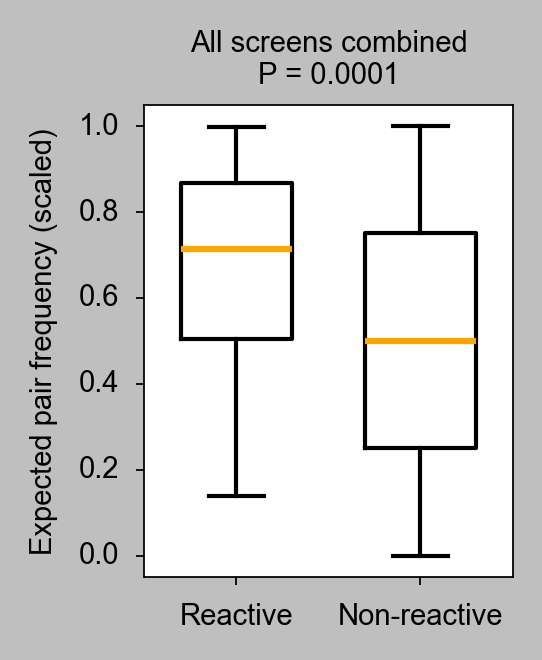

In [ ]:
ax, fig, gs = startfig(5, 6)

# Boxplot
ax.boxplot(
    [combined_validated, combined_not_validated],
    tick_labels=["Reactive", "Non-reactive"],
    widths=0.6,
    patch_artist=False,
    boxprops=dict(color="black", linewidth=1),
    whiskerprops=dict(color="black", linewidth=1, linestyle="-"),
    capprops=dict(color="black", linewidth=1),
    medianprops=dict(color="orange", linewidth=1.5),
    flierprops=dict(
        marker="o",
        markerfacecolor="black",
        markeredgecolor="black",
        markersize=3,
        alpha=0.5,
    ),
)

ax.tick_params(axis="both", labelsize=7)
ax.tick_params(top=False, right=False)
ax.set_ylabel("Expected pair frequency (scaled)", fontsize=7)
ax.set_ylim(-0.05, 1.05)
ax.set_title("All screens combined", fontsize=7)

stat, p = mannwhitneyu(
    combined_validated,
    combined_not_validated,
    alternative="two-sided"
)
print(f"U = {stat:.1f}, p = {p:.3e}")
p_label = f"All screens combined\nP = {p:.4f}"
ax.set_title(p_label, fontsize=7)


fig.tight_layout()

fig.savefig('/v1/figures/sup_fig_4_pdfs/boxplot_exp_prob_reactive_vs_non_reactive_combined_all_screens_ranked.pdf')

## Fig. 4a mixMHCpred3.0 analysis

In [ ]:
screened_minigene_aa_dict = defaultdict(dict)
with pysam.FastxFile('/minigene_assembly_datasets/mel-pt-b_nsclc-pt-c/mel-pt-b_nsclc-pt-c_twist_barcoded_p20_final_oligo_order_minigene_aa_seqs.fasta') as fasta_in: 
    for entry in fasta_in:
        if "mel_pt_b" in entry.name:
            screened_minigene_aa_dict["mel-pt-b"][remove_dna_barcode_from_string(entry.name, barcode_length = 18)] = entry.sequence
        if "nsclc-pt-c" in entry.name:
            screened_minigene_aa_dict["nsclc-pt-c"][remove_dna_barcode_from_string(entry.name, barcode_length = 18)] = entry.sequence


In [ ]:
print("mel_pt_b:", len(screened_minigene_aa_dict["mel-pt-b"]))
print("nsclc-pt-c:", len(screened_minigene_aa_dict["nsclc-pt-c"]))

In [ ]:
mel_pt_a_200_df = pd.read_excel('/references/T200_Ag200/T100_200_mel_pt_a_Ag.xlsx', index_col = 0)
mel_pt_a_names_list = (mel_pt_a_200_df["name"].str.split("_").str[0] + "_" + mel_pt_a_200_df["name"].str.split("_").str[1] + "_" + mel_pt_a_200_df["name"].str.split("_").str[2]).unique().tolist()

In [ ]:
mel_pt_a_200_df["minigene_aa"] = mel_pt_a_200_df["sequence"].str[35:-56].apply(
    lambda x: str(Seq(x).translate())
)
print(mel_pt_a_200_df["minigene_aa"].unique().shape[0])
mel_pt_a_200_df.drop_duplicates("minigene_aa", inplace = True)
print(mel_pt_a_200_df.shape[0])

199
199


In [ ]:
mel_pt_a_select_col_list = ["hugo_symbol", "aa_germline", "aa_tumor", "aa_pos_tumor_start", "peptide_context_germline", "peptide_context_tumor", "dna_vaf", "tpm"]

In [ ]:
mel_pt_a_df = pd.read_excel('/minigene_assembly_datasets/mel_pt_a_t500/Oligo library - mel_pt_a (93nt).xlsx', sheet_name = 1)
mel_pt_a_df = mel_pt_a_df.loc[:, mel_pt_a_select_col_list]

In [ ]:
print(mel_pt_a_200_df.shape[0])
mel_pt_a_200_df = pd.merge(mel_pt_a_200_df, mel_pt_a_df, left_on = "minigene_aa", right_on = "peptide_context_tumor", how = "left")
print(mel_pt_a_200_df.shape[0])
mel_pt_a_200_df.rename({"peptide_context_germline":"ref_prot", "tpm": "rna_tpm"}, axis = 1, inplace = True)
mel_pt_a_200_df["mut_id"] = mel_pt_a_200_df["hugo_symbol"] + "_" + mel_pt_a_200_df["aa_germline"] + mel_pt_a_200_df["aa_pos_tumor_start"].astype(str) + mel_pt_a_200_df["aa_tumor"]
print(mel_pt_a_200_df["mut_id"].isna().any())

199
200
True


In [ ]:
mel_pt_a_200_df.loc[mel_pt_a_200_df["mut_id"].isna(), :]

In [ ]:
mel_pt_a_200_df.loc[mel_pt_a_200_df["minigene_aa"] == "THPSFQDIMQNIDLVIGAELSVERVLEIIKQ", "mut_id"] = "DYM_SFFSSRLLQA394I"
mel_pt_a_200_df.loc[mel_pt_a_200_df["minigene_aa"] == "GTLGKFTVPMLKEACRAVGLKSGLKKQELLEALTKHFQD", "mut_id"] = "XRCC6_587fs"
mel_pt_a_200_df.loc[mel_pt_a_200_df["minigene_aa"] == "TLGKFTVPMLKEACRAVGLKSGLKKQELLEALTKHFQD", "mut_id"] = "XRCC6_538fs"
mel_pt_a_200_df.loc[mel_pt_a_200_df["minigene_aa"] == "LDMKSKLNTSKQAENGQPEPQNKVRLRTLH", "mut_id"] = "RC3H1_PAED1066V"
mel_pt_a_200_df.loc[mel_pt_a_200_df["minigene_aa"] == "RAGLLQQPPALGRGGSGGGPPAKRRLELGES", "mut_id"] = "E2F3_GG124G"

In [ ]:
mel_pt_a_200_df.loc[mel_pt_a_200_df["minigene_aa"].isin(["THPSFQDIMQNIDLVIGAELSVERVLEIIKQ", "GTLGKFTVPMLKEACRAVGLKSGLKKQELLEALTKHFQD", "TLGKFTVPMLKEACRAVGLKSGLKKQELLEALTKHFQD", "LDMKSKLNTSKQAENGQPEPQNKVRLRTLH", "RAGLLQQPPALGRGGSGGGPPAKRRLELGES"]), :]

In [ ]:
mel_pt_b_df = pd.read_excel('/minigene_assembly_datasets/hc_mel-pt-b/mel-pt-b.xlsx', sheet_name = 1)
col_select_list = ["mut_id", "alt_prot", "ref_prot", "rna_tpm"]
mel_pt_b_df = mel_pt_b_df.loc[:, col_select_list]
mel_pt_b_df.rename({"alt_prot": "minigene_aa"}, axis =1, inplace = True)

nsclc_pt_c_df = pd.read_excel('/minigene_assembly_datasets/nsclc-pt-c/nsclc-pt-c.xlsx', sheet_name = 1)
col_select_list = ["mut_id", "alt_prot", "ref_prot", "rna_tpm"]
nsclc_pt_c_df = nsclc_pt_c_df.loc[:, col_select_list]
nsclc_pt_c_df.rename({"alt_prot": "minigene_aa"}, axis =1, inplace = True)

In [ ]:
"COL21A1_471fs" in mel_pt_b_df["mut_id"]

False

In [ ]:
mel_pt_b_df.loc[mel_pt_b_df["mut_id"].str.contains("COL21A1"), :]

,mut_id,minigene_aa,ref_prot,rna_tpm
285,COL21A1_471fs,PKGDPGLPGNPGYPGNLVKMVSLDIRELQGHQVFQDLQEYKELEDY...,PKGDPGLPGNPGYPGQPGQDGKPGYQGIAGT,0.189614


In [ ]:
mel_pt_b_df.loc[mel_pt_b_df["mut_id"].str.contains("LRP8"), :]

,mut_id,minigene_aa,ref_prot,rna_tpm
27,LRP8_SK817RE,SPATSNHSQHYANEDREMGSTVTAAVIGIIVP,SPATSNHSQHYANEDSKMGSTVTAAVIGIIVP,10.0169
28,LRP8_SK742RE,MGPDMKRCYRDANEDREMGSTVTAAVIGIIVP,MGPDMKRCYRDANEDSKMGSTVTAAVIGIIVP,10.0169
29,LRP8_816fs,SISPSTLSPATSNHSQHYANELWNYVKRPNY,SISPSTLSPATSNHSQHYANEDSKMGSTVTAAVIGII,10.0169
30,LRP8_741fs,ACPDTMWLGPDMKRCYRDANELWNYVKRPNY,ACPDTMWLGPDMKRCYRDANEDSKMGSTVTAAVIGII,10.0169


In [ ]:
mel_pt_b_screened_df = pd.DataFrame.from_dict(
    screened_minigene_aa_dict["mel-pt-b"],
    orient="index",
    columns=["minigene_aa"]
)
mel_pt_b_screened_df = mel_pt_b_screened_df.reset_index().rename(columns={"index": "ag_name"})
mel_pt_b_df = pd.merge(mel_pt_b_screened_df, mel_pt_b_df, on = "minigene_aa", how = "left")
print(mel_pt_b_df.shape[0])


nsclc_pt_c_screened_df = pd.DataFrame.from_dict(
    screened_minigene_aa_dict["nsclc-pt-c"],
    orient="index",
    columns=["minigene_aa"]
)
nsclc_pt_c_screened_df = nsclc_pt_c_screened_df.reset_index().rename(columns={"index": "ag_name"})
nsclc_pt_c_df = pd.merge(nsclc_pt_c_screened_df, nsclc_pt_c_df, on = "minigene_aa", how = "left")
print(nsclc_pt_c_df.shape[0])

783
112


In [ ]:
mel_pt_b_df["mut_id"].str.contains("FLT3").any()

np.True_

In [ ]:
names_list = [
    "LRP8_816fs",
    "LRP8_741fs",
    "CELSR2_1175fs",
    "ZNF512_30fs",
    "CPO_88fs",
    "CPO_89fs",
    "BRD9_161fs",
    "BRD9_108fs",
    "SNX2_397fs",
    "COL21A1_471fs",
    "ZNF727_473fs",
    "MRPL15_296fs",
    "CDKN2A_68fs",
    "CDKN2A_82fs",
    "CDKN2A_68fs",
    "CARNMT1_201fs",
    "OSBP_709fs",
    "FLT3_296fs",
    "DAAM1_810fs",
    "MAPKBP1_678fs",
    "GEMIN4_620fs",
    "MYH3_1454fs",
    "USP22_369fs",
    "ELP2_658fs",
    "MUC16_3748fs",
    "IQCN_383fs",
    "ZNF766_445fs",
    "ATRX_1606fs",
    "TBX22_367fs",
]
pattern = "|".join(names_list)

mel_pt_b_df.loc[mel_pt_b_df["mut_id"].str.contains(pattern, na=False), :]

found = set(mel_pt_b_df["mut_id"].dropna())
missing = [name for name in names_list if name not in found]

print(f"{len(missing)} of {len(names_list)} names missing:")
for name in missing:
    print(name)

8 of 29 names missing:
CPO_88fs
COL21A1_471fs
MRPL15_296fs
CDKN2A_68fs
CDKN2A_82fs
CDKN2A_68fs
ELP2_658fs
ZNF766_445fs


In [ ]:
names_list = [
    "GATAD2B_352fs",
    "TPR_982fs",
    "RYR2_3841fs",
    "LRP2_2567fs",
    "TLL1_137fs",
    "PCDHA11_493fs",
    "ZNF292_418fs",
    "TRDN_496fs",
    "ENSG00000288520_457fs",
    "ZNF12_8fs",
    "SUPV3L1_574fs",
    "CCDC168_6698fs",
    "RHOJ_32fs",
    "EFCAB11_26fs",
    "EFCAB11_2fs",
    "NME3_43fs",
    "HSF4_183fs",
    "PRX_137fs",
    "ZNF8_420fs",
    "ZNF337_408fs",
    "OGT_503fs",
    "VGLL1_228fs",
]

pattern = "|".join(names_list)

nsclc_pt_c_df.loc[nsclc_pt_c_df["mut_id"].str.contains(pattern, na=False), :]

found = set(nsclc_pt_c_df["mut_id"].dropna())
missing = [name for name in names_list if name not in found]
found_2 = [name for name in names_list if name in found]

print(f"{len(missing)} of {len(names_list)} names missing:")
for name in missing:
    print(name)

20 of 22 names missing:
GATAD2B_352fs
RYR2_3841fs
LRP2_2567fs
TLL1_137fs
PCDHA11_493fs
ZNF292_418fs
TRDN_496fs
ENSG00000288520_457fs
ZNF12_8fs
SUPV3L1_574fs
CCDC168_6698fs
RHOJ_32fs
EFCAB11_26fs
EFCAB11_2fs
NME3_43fs
HSF4_183fs
PRX_137fs
ZNF8_420fs
ZNF337_408fs
VGLL1_228fs


In [41]:
found_2

['TPR_982fs', 'OGT_503fs']

In [ ]:
mel_pt_b_df.loc[mel_pt_b_df["mut_id"].isna(), :]

In [ ]:
# Manually fix 3 RNA fusion proteins that do not have an associated TPM nor WT aa sequence for comparison: 
mask = mel_pt_b_df["mut_id"].isna()

mel_pt_b_df.loc[mask, "rna_tpm"] = 0
mel_pt_b_df.loc[mask, "mut_id"] = mel_pt_b_df.loc[mask, "ag_name"].str.split("_").str[0] + mel_pt_b_df.loc[mask, "ag_name"].str.split("_").str[1] + mel_pt_b_df.loc[mask, "ag_name"].str.split("_").str[2]

print(mel_pt_b_df["ag_name"].duplicated().any())
## Encode WT fusions as fake NNNN deletions because fusions should be treated as neojunctions (determined boundry with uniprot blast):
mel_pt_b_df.loc[mel_pt_b_df["ag_name"] == "mel-pt-b_HACL1_COLQfs_789", "ref_prot"] = "SLINIMIEPQATRKAQNNNNPFPAWIRRSVVATKHAAC"
mel_pt_b_df.loc[mel_pt_b_df["ag_name"] == "mel-pt-b_HACL1_COLQfs_790", "ref_prot"] = "SLINIMIEPQATRKAQNNNNPFPAWIRRSVVATKHAAC"
mel_pt_b_df.loc[mel_pt_b_df["ag_name"] == "mel-pt-b_KANSL1_ARL17Afs_791", "ref_prot"] = "QAHVSDLEYRIRQQTDIYKQIRANKNNNNVSVWRQ"

False


In [ ]:
mel_pt_b_df.loc[(mel_pt_b_df["ag_name"] == "mel-pt-b_HACL1_COLQfs_789"), :]

In [ ]:
nsclc_pt_c_df.loc[nsclc_pt_c_df["mut_id"].isna(), :]

In [ ]:
# Manually fix RNA fusion proteins that do not have an associated TPM nor WT aa sequence for comparison: 
mask = nsclc_pt_c_df["mut_id"].isna()

nsclc_pt_c_df.loc[mask, "rna_tpm"] = 0
nsclc_pt_c_df.loc[mask, "mut_id"] = nsclc_pt_c_df.loc[mask, "ag_name"].str.split("_").str[0] + nsclc_pt_c_df.loc[mask, "ag_name"].str.split("_").str[1] + nsclc_pt_c_df.loc[mask, "ag_name"].str.split("_").str[2]

print(nsclc_pt_c_df["ag_name"].duplicated().any())
## Encode WT fusions as fake NNNN deletions because fusions should be treated as neojunctions (determined boundry with uniprot blast):
nsclc_pt_c_df.loc[nsclc_pt_c_df["ag_name"] == "nsclc-pt-c_BLNK_TLL2fs_461", "ref_prot"] = "KIKKLKVKAPPSVPRRDYASNNNNDRIKLHIHGFV"
nsclc_pt_c_df.loc[nsclc_pt_c_df["ag_name"] == "nsclc-pt-c_BPTF_LRRC37A2fs_462", "ref_prot"] = "TESSFRSHSTYSSTPNNNNEISKETIFLTLMEMYGKHTVGPRN" # uniprot less confident about this fusion
nsclc_pt_c_df.loc[nsclc_pt_c_df["ag_name"] == "nsclc-pt-c_HACL1_COLQfs_463", "ref_prot"] = "SLINIMIEPQATRKAQNNNNPFPAWIRRSVVATKHAAC"
nsclc_pt_c_df.loc[nsclc_pt_c_df["ag_name"] == "nsclc-pt-c_HACL1_COLQfs_464", "ref_prot"] = "SLINIMIEPQATRKAQNNNNPFPAWIRRSVVATKHAAC"
nsclc_pt_c_df.loc[nsclc_pt_c_df["ag_name"] == "nsclc-pt-c_KANSL1_ARL17Afs_465", "ref_prot"] = "QAHVSDLEYRIRQQTDIYKQIRANKNNNNVSVWRQ"
nsclc_pt_c_df.loc[nsclc_pt_c_df["ag_name"] == "nsclc-pt-c_MTG1_SCART1_467", "ref_prot"] = "VKLGKTQKVKVLTGTGNNNNGPGALRLAYRHSTCD"
nsclc_pt_c_df.loc[nsclc_pt_c_df["ag_name"] == "nsclc-pt-c_NSF_LRRC37A3fs_468", "ref_prot"] = "AESLQVTRGDFLASLENDIKPNNNNKFPRKLYFLH"
nsclc_pt_c_df.loc[nsclc_pt_c_df["ag_name"] == "nsclc-pt-c_NSF_LRRC37A3fs_469", "ref_prot"] = "AESLQVTRGDFLASLENDIKPNNNNKFPRKLYFLH" 
nsclc_pt_c_df.loc[nsclc_pt_c_df["ag_name"] == "nsclc-pt-c_TAF8_TJAP1fs_470", "ref_prot"] = "VTLVEMGFNVDTLPAYAKRSQRMVITANNNNRTPD"
nsclc_pt_c_df.loc[nsclc_pt_c_df["ag_name"] == "nsclc-pt-c_TAF8_TJAP1fs_471", "ref_prot"] = "VTLVEMGFNVDTLPAYAKRSQRMVITANNNNRTPD"

False


In [ ]:
id_counts = mel_pt_b_df.groupby("mut_id").cumcount()

mel_pt_b_df["mut_id"] = mel_pt_b_df["mut_id"].where(
    id_counts == 0,
    mel_pt_b_df["mut_id"] + "-" + (id_counts + 1).astype(str)
)

id_counts = nsclc_pt_c_df.groupby("mut_id").cumcount()

nsclc_pt_c_df["mut_id"] = nsclc_pt_c_df["mut_id"].where(
    id_counts == 0,
    nsclc_pt_c_df["mut_id"] + "-" + (id_counts + 1).astype(str)
)


id_counts = mel_pt_a_200_df.groupby("mut_id").cumcount()

mel_pt_a_200_df["mut_id"] = mel_pt_a_200_df["mut_id"].where(
    id_counts == 0,
    mel_pt_a_200_df["mut_id"] + "-" + (id_counts + 1).astype(str)
)

In [ ]:
mel_pt_a_reactive_df = pd.read_csv('/24_JH_mes_pairscan_variant_hit_analysis/mel-pt-a-200-vs-200_pairscan_reactive_pair_df_with_variant_annotation.csv',index_col = 0)
mel_pt_b_reactive_df = pd.read_csv('/24_JH_mes_pairscan_variant_hit_analysis/mel-pt-b_pairscan_reactive_pair_df_with_variant_annotation.csv', index_col = 0)
nsclc_pt_c_reactive_df = pd.read_csv('/24_JH_mes_pairscan_variant_hit_analysis/nsclc-pt-c_pairscan_reactive_pair_df_with_variant_annotation.csv', index_col = 0)

In [ ]:
mel_pt_a_reactive_df = mel_pt_a_reactive_df.loc[:, ["Epitope", "TCR", "Fold_change", "Pair", "validating_pair", "BH_Reject", "P_value_corrected", "P_value", "Exp_pair_prob", "peptide_context_tumor"]]
mel_pt_b_reactive_df = mel_pt_b_reactive_df.loc[:, ["Epitope", "TCR", "Fold_change", "Pair", "validating_pair", "BH_Reject", "P_value_corrected", "P_value", "Exp_pair_prob", "alt_prot"]]
nsclc_pt_c_reactive_df = nsclc_pt_c_reactive_df.loc[:, ["Epitope", "TCR", "Fold_change", "Pair", "validating_pair", "BH_Reject", "P_value_corrected", "P_value", "Exp_pair_prob", "alt_prot"]]

mel_pt_a_reactive_df.rename({"peptide_context_tumor": "minigene_aa"}, axis = 1, inplace = True)
mel_pt_b_reactive_df.rename({"alt_prot": "minigene_aa"}, axis = 1, inplace = True)
nsclc_pt_c_reactive_df.rename({"alt_prot": "minigene_aa"}, axis = 1, inplace = True)
mel_pt_a_reactive_df.drop_duplicates("Epitope", inplace = True)
mel_pt_b_reactive_df.drop_duplicates("Epitope", inplace = True)
nsclc_pt_c_reactive_df.drop_duplicates("Epitope", inplace = True)

In [ ]:
print(f"mel_pt_a before: {mel_pt_a_200_df.shape[0]}")
mel_pt_a_200_df = pd.merge(mel_pt_a_200_df, mel_pt_a_reactive_df, on = "minigene_aa", how = "left")
print(f"mel_pt_a after: {mel_pt_a_200_df.shape[0]}")

In [ ]:
print(f"Mel-Pt-B before: {mel_pt_b_df.shape[0]}")
mel_pt_b_df = pd.merge(mel_pt_b_df, mel_pt_b_reactive_df, on = "minigene_aa", how = "left")
print(f"Mel-Pt-B after: {mel_pt_b_df.shape[0]}")

In [ ]:
print(f"nsclc_pt_c before: {nsclc_pt_c_df.shape[0]}")
nsclc_pt_c_df = pd.merge(nsclc_pt_c_df, nsclc_pt_c_reactive_df, on = "minigene_aa", how = "left")
print(f"nsclc_pt_c after: {nsclc_pt_c_df.shape[0]}")

In [ ]:
ag_df_dict = {}
ag_df_dict["Mel-Pt-B"] = mel_pt_b_df
ag_df_dict["NSCLC-Pt-C"] = nsclc_pt_c_df
ag_df_dict["Mel-Pt-A"] = mel_pt_a_200_df

In [26]:
for patient in ag_df_dict.keys():
    ag_df_dict[patient] = align_to_add_var_start_and_end_aa_seq_ag_df(
        ag_df=ag_df_dict[patient], aa_var_seq_col="minigene_aa", aa_ref_seq_col="ref_prot", var_start_col="minigene_aa_var_start", var_end_col="minigene_aa_var_end"
    )

In [ ]:
mixmhcpred_exe = "/vscode_projects/MixMHCpred/MixMHCpred"

In [ ]:
minimal_epi_dir = Path('/experiments/25_mes_pairscan_minigene_screen_pMHC_binder_analysis')

In [ ]:
hc_patient_hla_dir = Path("//collected_HLA_typing")
hc_patient_hla_dict = {}
for hla_txt in hc_patient_hla_dir.glob("*.txt"):
    if len(hla_txt.stem.split("_HLA")[0].split("_")) == 2:
        patient = hla_txt.stem.split("_HLA")[0].split("_")[0] + hla_txt.stem.split("_HLA")[0].split("_")[1]
    elif len(hla_txt.stem.split("_HLA")[0].split("_")) == 1:
        patient = hla_txt.stem.split("_HLA")[0].split("_")[0]
    else:
        raise Exception("Split should return at least len 1", hla_txt.stem.split("_HLA")[0].split("_"), len(hla_txt.stem.split("_HLA")[0].split("_")))
    hc_patient_hla_dict[patient] = pd.read_csv(hla_txt, delimiter="\t")
    hc_patient_hla_dict[patient] = hc_patient_hla_dict[patient].loc[hc_patient_hla_dict[patient]["Class"].isin(["A", "B", "C"]), :]
    hc_patient_hla_dict[patient] = (
        hc_patient_hla_dict[patient]
        .replace("-", pd.NA)
        .dropna(subset=["germline (DNA)"])
        .assign(n=hc_patient_hla_dict[patient].groupby("Class").cumcount())
        .pivot(index="Class", columns="n", values="germline (DNA)")
        .rename(columns={0: "allele1", 1: "allele2"})
        .reindex(columns=["allele1", "allele2"])
        .reset_index(drop=True)
    )

    hc_patient_hla_dict[patient][["allele1", "allele2"]] = hc_patient_hla_dict[patient][["allele1", "allele2"]].astype("string")

    hc_patient_hla_dict[patient]["allele_1_mix_enc"] = (
        hc_patient_hla_dict[patient]["allele1"].str.extract(r"([A-Z])\*(\d{2}):(\d{2})").fillna("").agg("".join, axis=1).replace("", pd.NA)
    )

    hc_patient_hla_dict[patient]["allele_2_mix_enc"] = (
        hc_patient_hla_dict[patient]["allele2"].str.extract(r"([A-Z])\*(\d{2}):(\d{2})").fillna("").agg("".join, axis=1).replace("", pd.NA)
    )

    hc_patient_hla_dict[patient]["patient"] = patient

hc_patient_hla_df = pd.concat(hc_patient_hla_dict.values(), ignore_index=True)

In [ ]:
hc_patient_hla_df["patient"].unique()

In [ ]:
hc_patient_hla_df = hc_patient_hla_df.loc[hc_patient_hla_df["patient"].isin(["Mel-Pt-B", "NSCLC-Pt-C"]), :]

In [ ]:
data = [
    {
        "patient": "Mel-Pt-A",
        "gene": "HLA-A",
        "allele_1_mix_enc": "A2902",
        "allele_2_mix_enc": "A0201",
    },
    {
        "patient": "Mel-Pt-A",
        "gene": "HLA-B",
        "allele_1_mix_enc": "B4402",
        "allele_2_mix_enc": "B5101",
    },
    {
        "patient": "Mel-Pt-A",
        "gene": "HLA-C",
        "allele_1_mix_enc": "C0704",
        "allele_2_mix_enc": "C0202",
    },
]

patient_hla_df = pd.DataFrame(data)

In [33]:
patient_hla_df = patient_hla_df.drop(["gene"], axis = 1)
hc_patient_hla_df = hc_patient_hla_df.drop(["allele1", "allele2"], axis = 1)

In [ ]:
patient_hla_df = pd.concat([patient_hla_df, hc_patient_hla_df])
patient_hla_df

In [ ]:
ag_df_dict["Mel-Pt-A"].loc[ag_df_dict["Mel-Pt-A"]["mut_id"].isna(), :]

,name,sequence,barcode,minigene_aa,hugo_symbol,aa_germline,aa_tumor,aa_pos_tumor_start,ref_prot,peptide_context_tumor,...,Fold_change,Pair,validating_pair,BH_Reject,P_value_corrected,P_value,Exp_pair_prob,minigene_aa_var_start,minigene_aa_var_end,var_type_for_kmer_overlap_col


In [ ]:
hc_patient_hla_df

In [ ]:
mixmhcpred_out_txt_list = run_mixmhcpred_patient_df_dict(
    patient_df_dict=ag_df_dict,
    patient_hla_df=patient_hla_df,
    run_dir=minimal_epi_dir,
    kmer_list=[8, 9, 10, 11],
    gene_id_col="mut_id",
    aa_seq_col="minigene_aa",
    hla_df_patient_col="patient",
    allele_1_col="allele_1_mix_enc",
    allele_2_col="allele_2_mix_enc",
    mixmhcpred_exe=mixmhcpred_exe,
    variant=True,
    minigene_aa_var_start_col="minigene_aa_var_start",
    minigene_aa_var_end_col="minigene_aa_var_end",
    var_type_for_kmer_overlap_col="var_type_for_kmer_overlap_col",
)

In [38]:
include_cols_patient_df_list = ["minigene_aa", "ref_prot", "minigene_aa_var_start", "minigene_aa_var_end", "var_type_for_kmer_overlap_col", "Epitope", "TCR", "Fold_change", "Pair", "validating_pair", "BH_Reject", "P_value_corrected", "P_value", "Exp_pair_prob"]

In [39]:
parsed_csv_list = parse_mixmhcpred_out_txt_list(
    mixmhcpred_out_txt_list=mixmhcpred_out_txt_list,
    patient_df_dict=ag_df_dict,
    gene_id_col="mut_id",
    mrna_expression_col="rna_tpm",
    keep_top_number_peptides=1087, # this is an arbritary number that does nothing in this case
    include_cols_patient_df_list=include_cols_patient_df_list,
    rank_by_binning=False,
    mrna_sorting_weight=0.2,
    percent_rank_threshold=101,
    hit_col=None, 
    confident_binder_percent_rank_threshold=0.5,
)

In [ ]:
mel_pt_a_mix_df = pd.read_csv('/25_mes_pairscan_minigene_screen_pMHC_binder_analysis/mixmhcpred/mel-pt-a_parsed_and_sorted_peptides_df.csv')
mel_pt_b_mix_df = pd.read_csv('/25_mes_pairscan_minigene_screen_pMHC_binder_analysis/mixmhcpred/mel-pt-b_parsed_and_sorted_peptides_df.csv')
nsclc_pt_c_mix_df = pd.read_csv('/25_mes_pairscan_minigene_screen_pMHC_binder_analysis/mixmhcpred/nsclc-pt-c_parsed_and_sorted_peptides_df.csv')

In [ ]:
mel_pt_a_min_rank_df = (
    mel_pt_a_mix_df.loc[
        mel_pt_a_mix_df.groupby("mut_id")["%Rank_bestAllele"].idxmin()
    ]
)

mel_pt_b_min_rank_df = (
    mel_pt_b_mix_df.loc[
        mel_pt_b_mix_df.groupby("mut_id")["%Rank_bestAllele"].idxmin()
    ]
)

nsclc_pt_c_min_rank_df = (
    nsclc_pt_c_mix_df.loc[
        nsclc_pt_c_mix_df.groupby("mut_id")["%Rank_bestAllele"].idxmin()
    ]
)


mel_pt_a_min_rank_df["patient"] = "mel-pt-a"
mel_pt_b_mix_df["patient"] = "mel-pt-b"
nsclc_pt_c_mix_df["patient"] = "nsclc-pt-c"

combined_min_rank_df = pd.concat(
    [mel_pt_a_min_rank_df, mel_pt_b_min_rank_df, nsclc_pt_c_min_rank_df],
    ignore_index=True
)

combined_mix_df = pd.concat([mel_pt_a_min_rank_df, mel_pt_b_min_rank_df, nsclc_pt_c_min_rank_df])
combined_mix_df.drop_duplicates('mut_id', inplace = True)

U = 615.0, p = 6.30301e-06


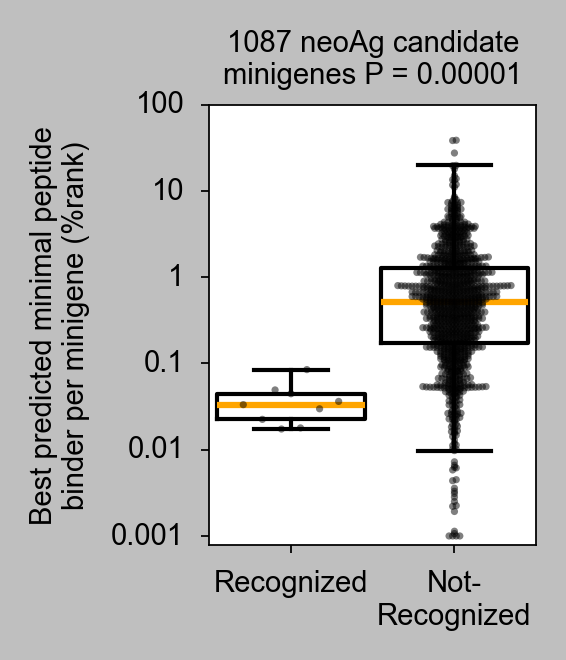

In [ ]:
ax, fig, gs = startfig(5.2, 6)

reactive = combined_min_rank_df.loc[
    combined_min_rank_df["validating_pair"] == 1.0, "%Rank_bestAllele"
]
not_reactive = combined_min_rank_df.loc[
    combined_min_rank_df["validating_pair"] != 1.0, "%Rank_bestAllele"
]

reactive_log = np.log10(reactive)
not_reactive_log = np.log10(not_reactive)

ax.boxplot(
    [reactive_log, not_reactive_log],
    tick_labels=["Recognized", "Not-\nRecognized"],
    widths=0.9,
    patch_artist=False,
    boxprops=dict(color="black", linewidth=1),
    whiskerprops=dict(color="black", linewidth=1, linestyle="-"),
    capprops=dict(color="black", linewidth=1),
    medianprops=dict(color="orange", linewidth=1.5),
    showfliers=False,
)

# Add beeswarm
reactive_x = simple_beeswarm2(reactive_log, width=0.35)
not_reactive_x = simple_beeswarm2(not_reactive_log, width=0.35)

ax.scatter(
    1 + reactive_x,
    reactive_log,
    s=3,
    color="black",
    alpha=0.5,
    zorder=3,
    edgecolors='none'
)

ax.scatter(
    2 + not_reactive_x,
    not_reactive_log,
    s=3,
    color="black",
    alpha=0.5,
    zorder=3,
    edgecolors='none'
)

# Relabel log10 axis
ax.set_yticks([-3, -2, -1, 0, 1, 2])
ax.set_yticklabels(["0.001", "0.01", "0.1", "1", "10", "100"])
ax.set_ylim(-3.1, 2)

ax.tick_params(axis="both", labelsize=7)
ax.tick_params(top=False, right=False)

stat, p = mannwhitneyu(
    reactive,
    not_reactive,
    alternative="two-sided"
)

#ax.axhline(np.log10(38.615963), color = "red")
ax.set_ylabel("Best predicted minimal peptide\nbinder per minigene (%rank)", fontsize = 7)
print(f"U = {stat:.1f}, p = {p:.5e}")
p_label = f"{combined_min_rank_df.shape[0]} neoAg candidate\nminigenes P = {p:.5f}"
ax.set_title(p_label, fontsize=7)

fig.tight_layout()
fig.savefig('/v1/figures/fig_3_pdfs/percent_rankbestallele_best_minimal_peptide_mel-pt-ab_nsclc-pt-c_pairscan_reactive_vs_not.pdf')

## Extended Data Fig. 1d, Median number of CD8 TCR clonotypes vs median CD8 density/mm2 in whole slide images DFCI dataset across cancer types

In [ ]:
hist_df = pd.read_csv('/v1/figures/sup_fig_1_pdfs/Job-1004336929561134815795950811.csv')
df = pd.DataFrame(hist_df.groupby("cancer_type")["cd8_density"].median().sort_values())
df.index = df.index.str.split(" Cancer").str[0]
df["cancer"] = df.index

In [ ]:
fig1a_df = pd.read_csv('/v1/figures/sup_fig_1_pdfs/cd8_patient_summary_downsampled.csv')
fig1a_df = (
    fig1a_df.groupby("tumor_type")["n_cd8"]
    .median()
    .sort_values()
    .reset_index()
    .rename(columns={"tumor_type": "cancer_type"})
)

#fig1a_df["cancer_type"] = fig1a_df.index

In [4]:
cancer_rename_map = {

    "Breast": "Breast", 
    "Endometrial": "Endometrium",
    "Melanoma": "Melanoma",
    "Renal Cell Carcinoma":"Kidney clear cell",
    #"Non-Small Cell Lung": "Lung squamous",
    "Non-Small Cell Lung": "Lung adenocarcinoma",
    "Prostate": "Prostate",
    "Esophagogastric":"Esophagus", 
    "Ovarian":"Ovary", 
    "Bladder": "Bladder",
    "Colorectal": "Colon",
    "Pancreatic": "Pancreas",
}

In [5]:
df["cancer"] = df["cancer"].map(cancer_rename_map)
df = df.dropna(subset = "cancer")
df = pd.merge(fig1a_df, df, left_on = "cancer_type", right_on = "cancer")

In [6]:
color_map = {"Thyroid": "#F8EF6D", 
 "Breast": "#DF62A3", 
 "Endometrium":"#F0C790",
 "Melanoma": "#CADB7A",
     "Kidney clear cell": "#F1C1C3",
     #"Lung squamous": 300,
     "Lung adenocarcinoma": "#D9D0E5",
     "Prostate": "#8D4C48",
     "Esophagus": "#5E96C0",
     "Ovary": "#D49860",
     "Bladder": "#F5DDE1",
     "Colon": "#BAE0F5",
     "Pancreas": "#8D95B2",
 }
 

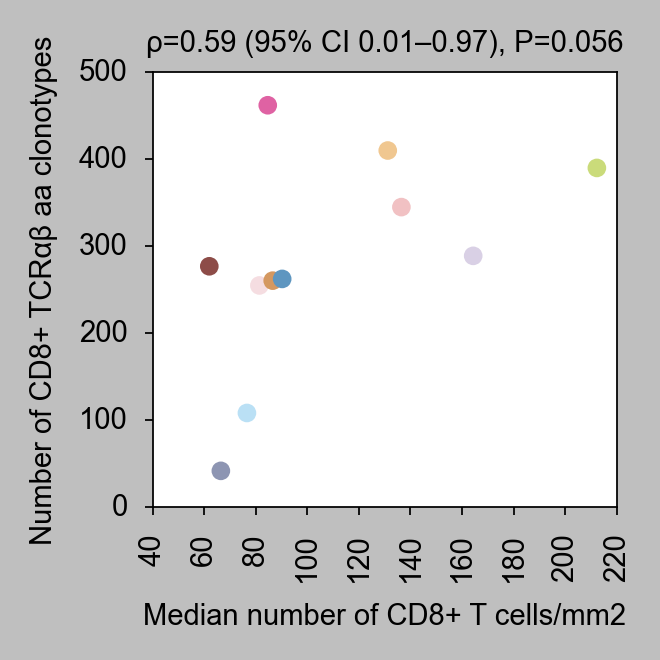

In [ ]:
ax, fig, gs = startfig(6, 6)

ax.scatter(df["cd8_density"], df["n_cd8"], edgecolors='none', 
           color = [color_map[cancer] for cancer in df["cancer_type"]])
ax.tick_params('both', labelsize=7)
ax.tick_params('x', rotation = 90)
ax.set_xlabel("Median number of CD8+ T cells/mm2", fontsize=7)
ax.set_ylabel("Number of CD8+ TCRαβ aa clonotypes", fontsize=7)
ax.tick_params(top=False, right=False)

rho, pval = spearmanr(df["cd8_density"], df["n_cd8"], nan_policy='omit')

# Bootstrap CI for rho (paired resampling, drop NaNs first so nan_policy isn't needed)
mask = df["cd8_density"].notna() & df["n_cd8"].notna()
x = df.loc[mask, "cd8_density"].to_numpy()
y = df.loc[mask, "n_cd8"].to_numpy()

n_boot = 10_000
rng = np.random.default_rng(0)
boot_rhos = np.empty(n_boot)
n = len(x)
for i in range(n_boot):
    idx = rng.integers(0, n, n)
    boot_rhos[i] = spearmanr(x[idx], y[idx])[0]

ci_lo, ci_hi = np.nanpercentile(boot_rhos, [2.5, 97.5])

ax.set_title(f"ρ={rho:.2f} (95% CI {ci_lo:.2f}–{ci_hi:.2f}), P={pval:.2g}", fontsize = 7)
fig.tight_layout()
fig.savefig('/v1/figures/sup_fig_1_pdfs/cd8_density_versus_number_of_cd8_t_cells_detected.pdf')